# 📊 Report Figures Generator
## Amazon Best Seller Rank Prediction using Multimodal Analysis

**Run all cells at once to generate all figures for the research paper.**

Figures included:
- Figure 4: Clutter Score Comparison (Low vs High)
- Figure 5: Feature Correlation Heatmap (Top 20 Features)
- Figure 6: BSR Distribution (Raw vs Log-Transformed)
- Figure 7: BSR Distribution by Image Count Bins
- Figure 8: Confusion Matrix Heatmap
- Figure 9: Actual vs Predicted log(BSR) Scatter Plot
- Figure 10: Feature Importances by Category
- Figure 11: ROC Curve with AUC Annotation
- Figure 12: Residuals Distribution with Normal Curve
- Figure 13: Cross-Validation Stability Analysis

Appendix Figures:
- Figure 14: Complete Feature Table
- Figure 15: Grid Search Heatmap
- Figure 16: Category Performance Comparison
- Figure 17: Prediction Cards for Example Products

In [ ]:
# ============================================================
# CELL 1: SETUP AND IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textstat
import warnings
import os
from PIL import Image
import glob

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, r2_score, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor
from scipy import stats

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [ ]:
# ============================================================
# CELL 2: LOAD DATA
# ============================================================

# Load main datasets
image_df = pd.read_csv('./../../data/image_analysis_data/yolo_update_data.csv')
full_df = pd.read_csv('./../../data/data_with_scraper.csv')

print(f"✓ Image data: {len(image_df)} products")
print(f"✓ Full data: {len(full_df)} products")

✓ Image data: 19049 products
✓ Full data: 17375 products


In [ ]:
# ============================================================
# CELL 3: FEATURE ENGINEERING
# ============================================================

# NLP Features
full_df["title_char_len"] = full_df["item_name"].str.len()
full_df["title_word_len"] = full_df["item_name"].str.split().str.len()
full_df["title_avg_word"] = full_df["title_char_len"] / full_df["title_word_len"]
full_df["sentiment_char_len"] = full_df["sd_customer_sentiments"].fillna("").str.len()

# Keyword flags
full_df["title_has_premium"] = full_df["item_name"].str.contains("premium|luxury|pro", case=False, na=False).astype(int)
full_df["title_has_set"] = full_df["item_name"].str.contains("set|bundle|pack", case=False, na=False).astype(int)
full_df["title_has_new"] = full_df["item_name"].str.contains("new|202|latest", case=False, na=False).astype(int)
full_df["title_has_size"] = full_df["item_name"].str.contains(r"\d+\s?(ml|oz|pack|pcs)", case=False, na=False).astype(int)

# Sentiment extraction
def extract_sentiment_counts(text):
    if pd.isna(text) or text == "" or text == "[]":
        return pd.Series({"sent_pos": 0, "sent_neg": 0, "sent_mixed": 0, "sent_total": 0})
    try:
        data = json.loads(text)
        sentiments = [d.get("sentiment", "").upper() for d in data]
        pos = sum(s == "POSITIVE" for s in sentiments)
        neg = sum(s == "NEGATIVE" for s in sentiments)
        mixed = sum(s == "MIXED" for s in sentiments)
        return pd.Series({"sent_pos": pos, "sent_neg": neg, "sent_mixed": mixed, "sent_total": pos + neg + mixed})
    except Exception:
        return pd.Series({"sent_pos": 0, "sent_neg": 0, "sent_mixed": 0, "sent_total": 0})

sentiment_features = full_df["sd_customer_sentiments"].apply(extract_sentiment_counts)
full_df = pd.concat([full_df, sentiment_features], axis=1)

# Readability scores
full_df["title_readability"] = full_df["item_name"].fillna("").apply(textstat.flesch_reading_ease)
full_df["title_syllables"] = full_df["item_name"].fillna("").apply(textstat.syllable_count)

print("✓ NLP features created")

✓ NLP features created


In [ ]:
# ============================================================
# CELL 4: MERGE AND PREPARE DATA
# ============================================================

# Prepare numeric datasets
full_df2 = full_df.drop(columns=["Unnamed: 0"], errors="ignore")
full_numeric = pd.concat([full_df2[["asin"]], full_df2.select_dtypes(include=["number"])], axis=1)

image_df2 = image_df.drop(columns=["Unnamed: 0", "keyword", "source_file", "item_name", "brand", 
                                    "main_image_url", "product_url", "image_list", "image_path"], errors="ignore")
image_numeric = pd.concat([image_df2[["asin"]], image_df2.select_dtypes(include=["number"])], axis=1)

# Merge datasets
final_df = full_numeric.merge(image_numeric, on="asin", how="inner", suffixes=("_full", "_img"))
final_df = final_df.dropna(axis=1, how="all")

# Create target variable
final_df["has_bsr_flag"] = final_df["bsr_best_full"].notna().astype(int)

# Also merge with original full_df for category info
final_df_with_meta = final_df.merge(
    full_df[["asin", "item_name", "brand", "keyword"]].drop_duplicates(subset="asin"),
    on="asin", how="left"
)

print(f"✓ Final dataset: {len(final_df)} products, {len(final_df.columns)} columns")

✓ Final dataset: 19336 products, 66 columns


In [ ]:
# ============================================================
# CELL 5: PREPARE FEATURES AND TRAIN CLASSIFIER
# ============================================================

# Define leak columns
leak_cols = [
    "bsr_best", "bsr_best_full", "bsr_best_img", "bsr_paths",
    "units_per_month", "sales_velocity_daily", "sd_number_bought_past_month",
    "sd_price", "sd_list_price", "sd_previous_price",
    "sd_average_rating", "sd_total_reviews", "sd_ratings_count", "sd_stars",
    "sent_pos", "sent_neg", "sent_mixed", "sent_total", "sentiment_char_len",
]

# Classification data
X = final_df.drop(columns=leak_cols + ["has_bsr_flag", "asin"], errors="ignore").fillna(0)
y = final_df["has_bsr_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train XGBoost Classifier
clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    n_jobs=4,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred_clf = clf.predict(X_test)
y_pred_clf_proba = clf.predict_proba(X_test)[:, 1]

print(f"✓ XGBoost Classifier trained")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_clf):.3f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_pred_clf_proba):.3f}")

✓ XGBoost Classifier trained
  Accuracy: 0.898
  ROC AUC: 0.849


In [ ]:
# ============================================================
# CELL 6: TRAIN REGRESSION MODEL
# ============================================================

# Regression data - only ranked products
df_ranked = final_df[final_df["bsr_best_full"].notna()].copy()
X_reg = df_ranked.drop(columns=leak_cols + ["has_bsr_flag", "asin"], errors="ignore").fillna(0)
y_reg = np.log1p(df_ranked["bsr_best_full"])

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train XGBoost Regressor
reg = XGBRegressor(
    n_estimators=500,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=42
)
reg.fit(X_reg_train, y_reg_train)

y_pred_reg = reg.predict(X_reg_test)
r2_test = r2_score(y_reg_test, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))

print(f"✓ XGBoost Regressor trained")
print(f"  R²: {r2_test:.3f}")
print(f"  RMSE: {rmse_test:.3f}")
print("\n" + "="*60)
print("MODELS READY - NOW GENERATING FIGURES")
print("="*60)

✓ XGBoost Regressor trained
  R²: 0.270
  RMSE: 1.753

MODELS READY - NOW GENERATING FIGURES


---
# 📈 FIGURE 4: Clutter Score Comparison (Low vs High)
---

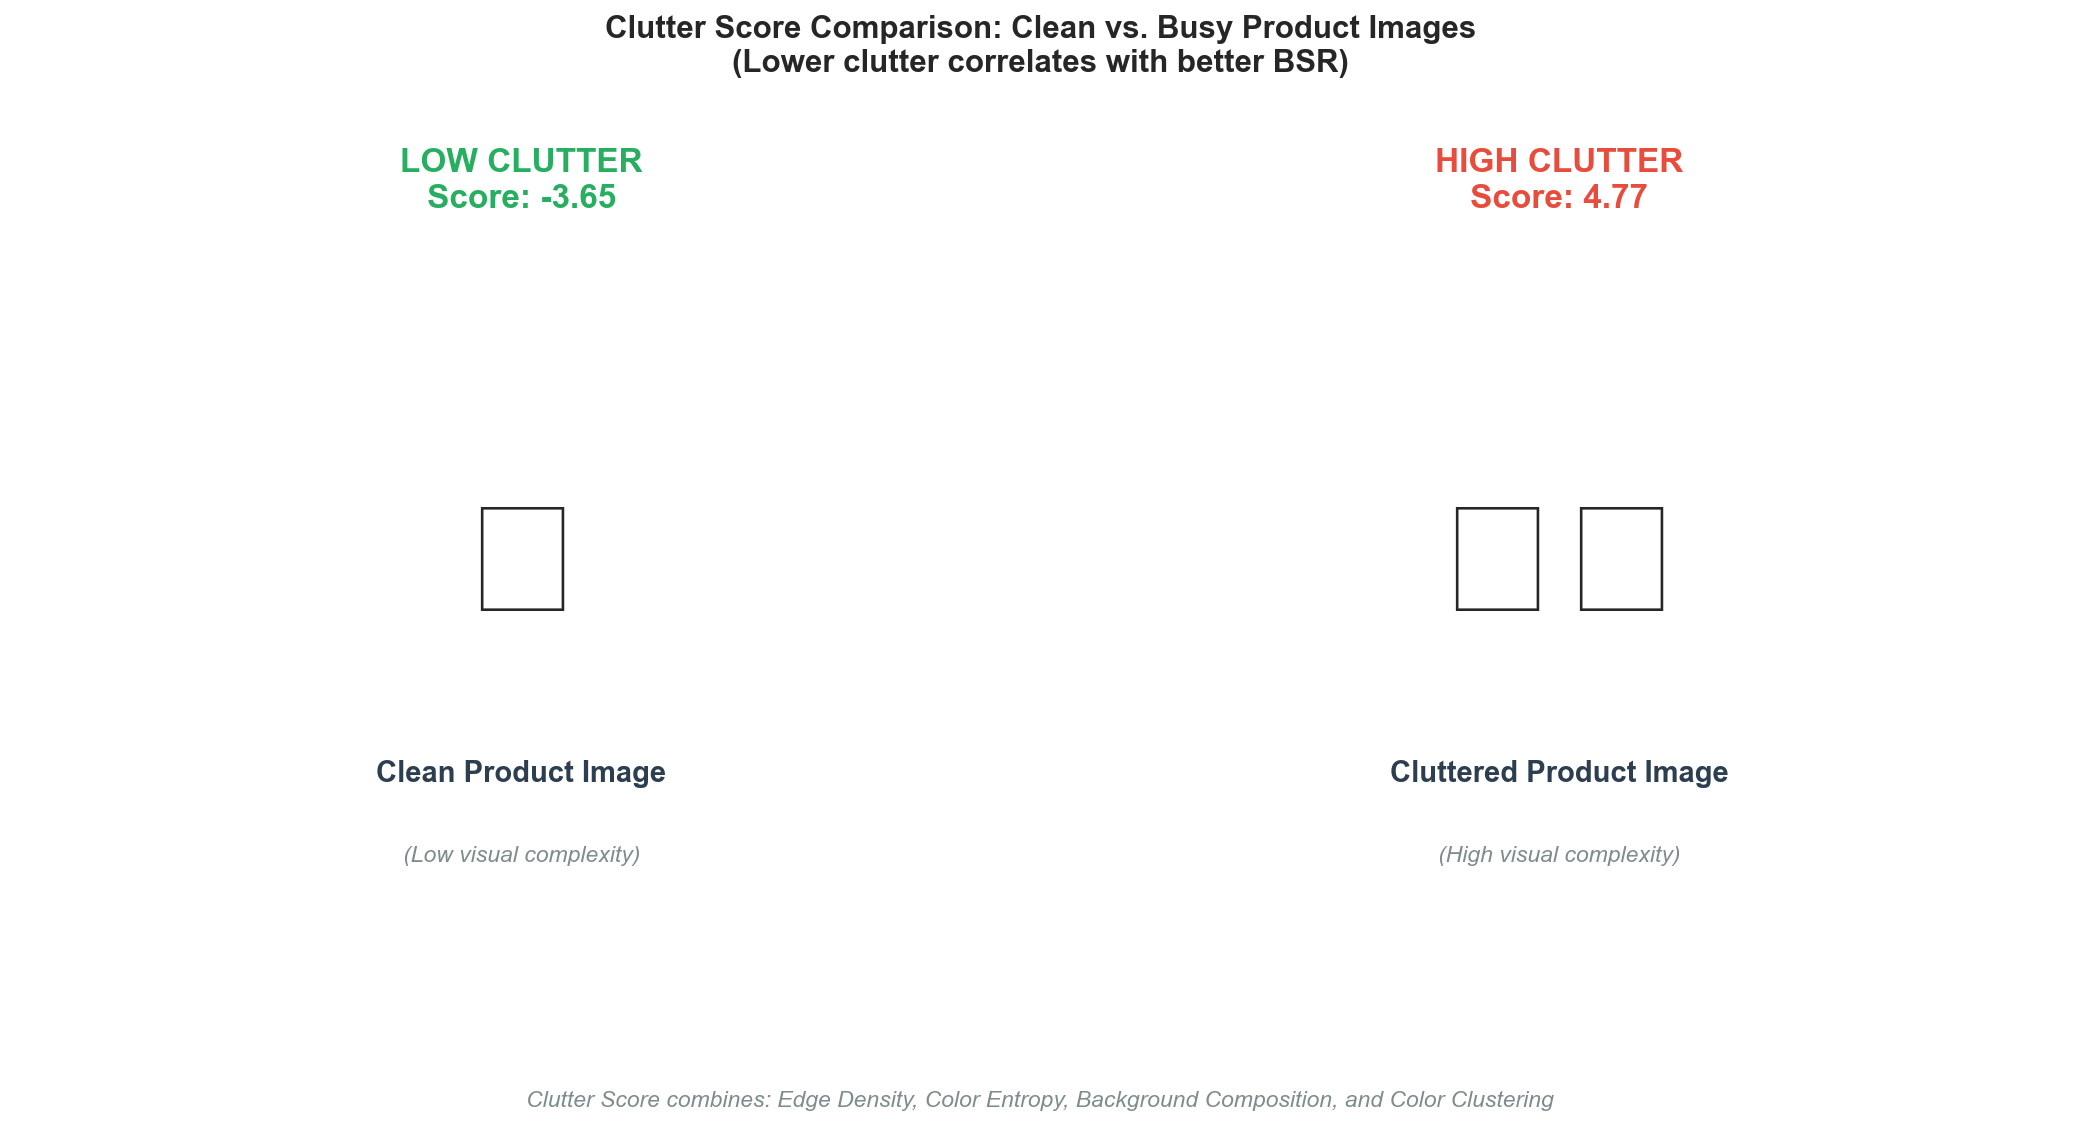


[FIGURE 4: Clutter Score Comparison]
Low Clutter Product:
  ASIN: B09FRQZCY7
  Clutter Score: -3.653

High Clutter Product:
  ASIN: 1888840145
  Clutter Score: 4.773

Score Difference: 8.425


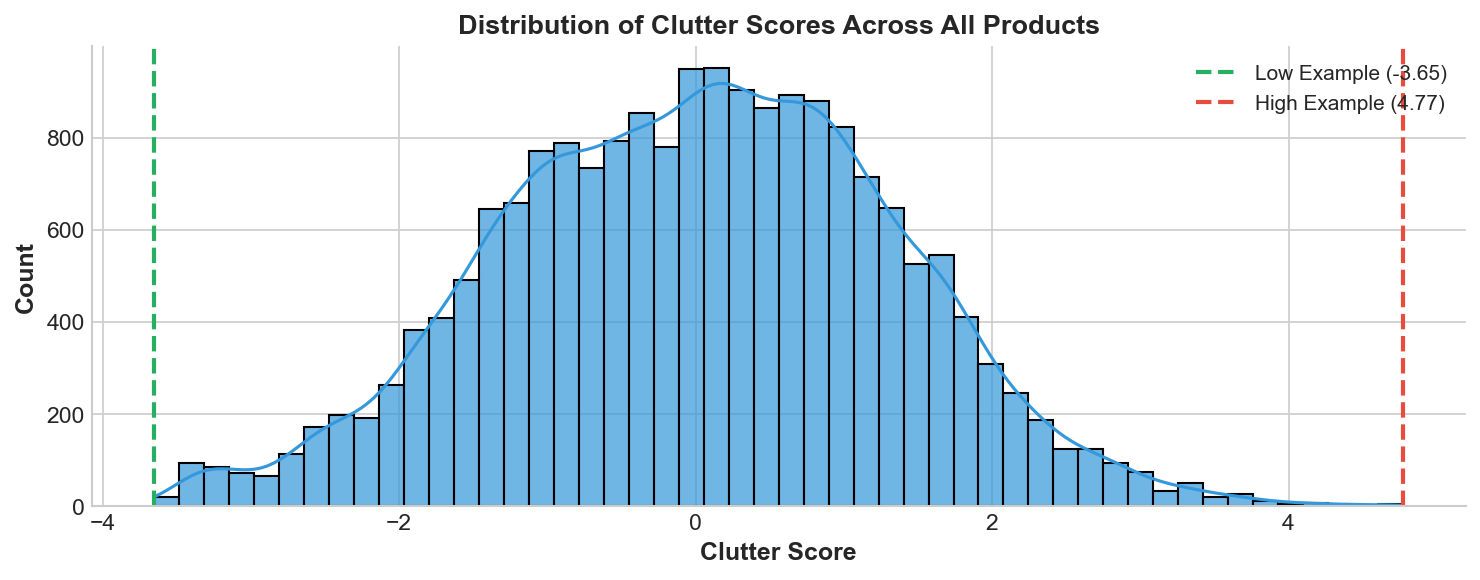


[Additional: Clutter Score Distribution with Examples Marked]


In [ ]:
# ============================================================
# FIGURE 4: Clutter Score Comparison (Low vs High)
# ============================================================

# Get products with clutter scores
clutter_df = image_df[['asin', 'clutter_score', 'image_path', 'main_image_url']].dropna(subset=['clutter_score'])

# Find low and high clutter examples
low_clutter = clutter_df.nsmallest(10, 'clutter_score').iloc[0]
high_clutter = clutter_df.nlargest(10, 'clutter_score').iloc[0]

# Try to load images from local paths or show placeholder
def load_image_safe(row):
    """Try to load image from local path"""
    if 'image_path' in row and pd.notna(row['image_path']):
        path = row['image_path']
        possible_paths = [path, f"./../../data/images_amz/{row['asin']}.jpg", f"./../../data/images_amz/{row['asin']}.png"]
        for p in possible_paths:
            if os.path.exists(p):
                try:
                    return Image.open(p)
                except:
                    pass
    image_dir = "./../../data/images_amz/"
    if os.path.exists(image_dir):
        matches = glob.glob(f"{image_dir}*{row['asin']}*")
        if matches:
            try:
                return Image.open(matches[0])
            except:
                pass
    return None

# Load images
img_low = load_image_safe(low_clutter)
img_high = load_image_safe(high_clutter)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Low clutter image
ax1 = axes[0]
if img_low is not None:
    ax1.imshow(img_low)
else:
    ax1.set_facecolor('#F8F9FA')
    ax1.text(0.5, 0.6, '📷', fontsize=80, ha='center', va='center', transform=ax1.transAxes)
    ax1.text(0.5, 0.35, 'Clean Product Image', fontsize=14, ha='center', va='center', transform=ax1.transAxes, color='#2C3E50', fontweight='bold')
    ax1.text(0.5, 0.25, '(Low visual complexity)', fontsize=11, ha='center', va='center', transform=ax1.transAxes, color='#7F8C8D', style='italic')
ax1.axis('off')
score_low = low_clutter['clutter_score']
ax1.set_title(f'LOW CLUTTER\nScore: {score_low:.2f}', fontsize=16, fontweight='bold', color='#27AE60', pad=15)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('#27AE60')
    spine.set_linewidth(4)

# High clutter image
ax2 = axes[1]
if img_high is not None:
    ax2.imshow(img_high)
else:
    ax2.set_facecolor('#F8F9FA')
    ax2.text(0.5, 0.6, '🖼️', fontsize=80, ha='center', va='center', transform=ax2.transAxes)
    ax2.text(0.5, 0.35, 'Cluttered Product Image', fontsize=14, ha='center', va='center', transform=ax2.transAxes, color='#2C3E50', fontweight='bold')
    ax2.text(0.5, 0.25, '(High visual complexity)', fontsize=11, ha='center', va='center', transform=ax2.transAxes, color='#7F8C8D', style='italic')
ax2.axis('off')
score_high = high_clutter['clutter_score']
ax2.set_title(f'HIGH CLUTTER\nScore: {score_high:.2f}', fontsize=16, fontweight='bold', color='#E74C3C', pad=15)
for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('#E74C3C')
    spine.set_linewidth(4)

plt.suptitle('Clutter Score Comparison: Clean vs. Busy Product Images\n(Lower clutter correlates with better BSR)', fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.02, 'Clutter Score combines: Edge Density, Color Entropy, Background Composition, and Color Clustering', ha='center', fontsize=11, style='italic', color='#7F8C8D')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 4: Clutter Score Comparison]")
print("="*60)
print(f"Low Clutter Product:")
print(f"  ASIN: {low_clutter['asin']}")
print(f"  Clutter Score: {score_low:.3f}")
print(f"\nHigh Clutter Product:")
print(f"  ASIN: {high_clutter['asin']}")
print(f"  Clutter Score: {score_high:.3f}")
print(f"\nScore Difference: {score_high - score_low:.3f}")

# Show clutter score distribution
fig2, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clutter_df['clutter_score'], bins=50, kde=True, ax=ax, color='#3498DB', alpha=0.7)
ax.axvline(score_low, color='#27AE60', linestyle='--', linewidth=2, label=f'Low Example ({score_low:.2f})')
ax.axvline(score_high, color='#E74C3C', linestyle='--', linewidth=2, label=f'High Example ({score_high:.2f})')
ax.set_xlabel('Clutter Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Clutter Scores Across All Products', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("\n[Additional: Clutter Score Distribution with Examples Marked]")

---
# 📈 FIGURE 5: Feature Correlation Heatmap
---

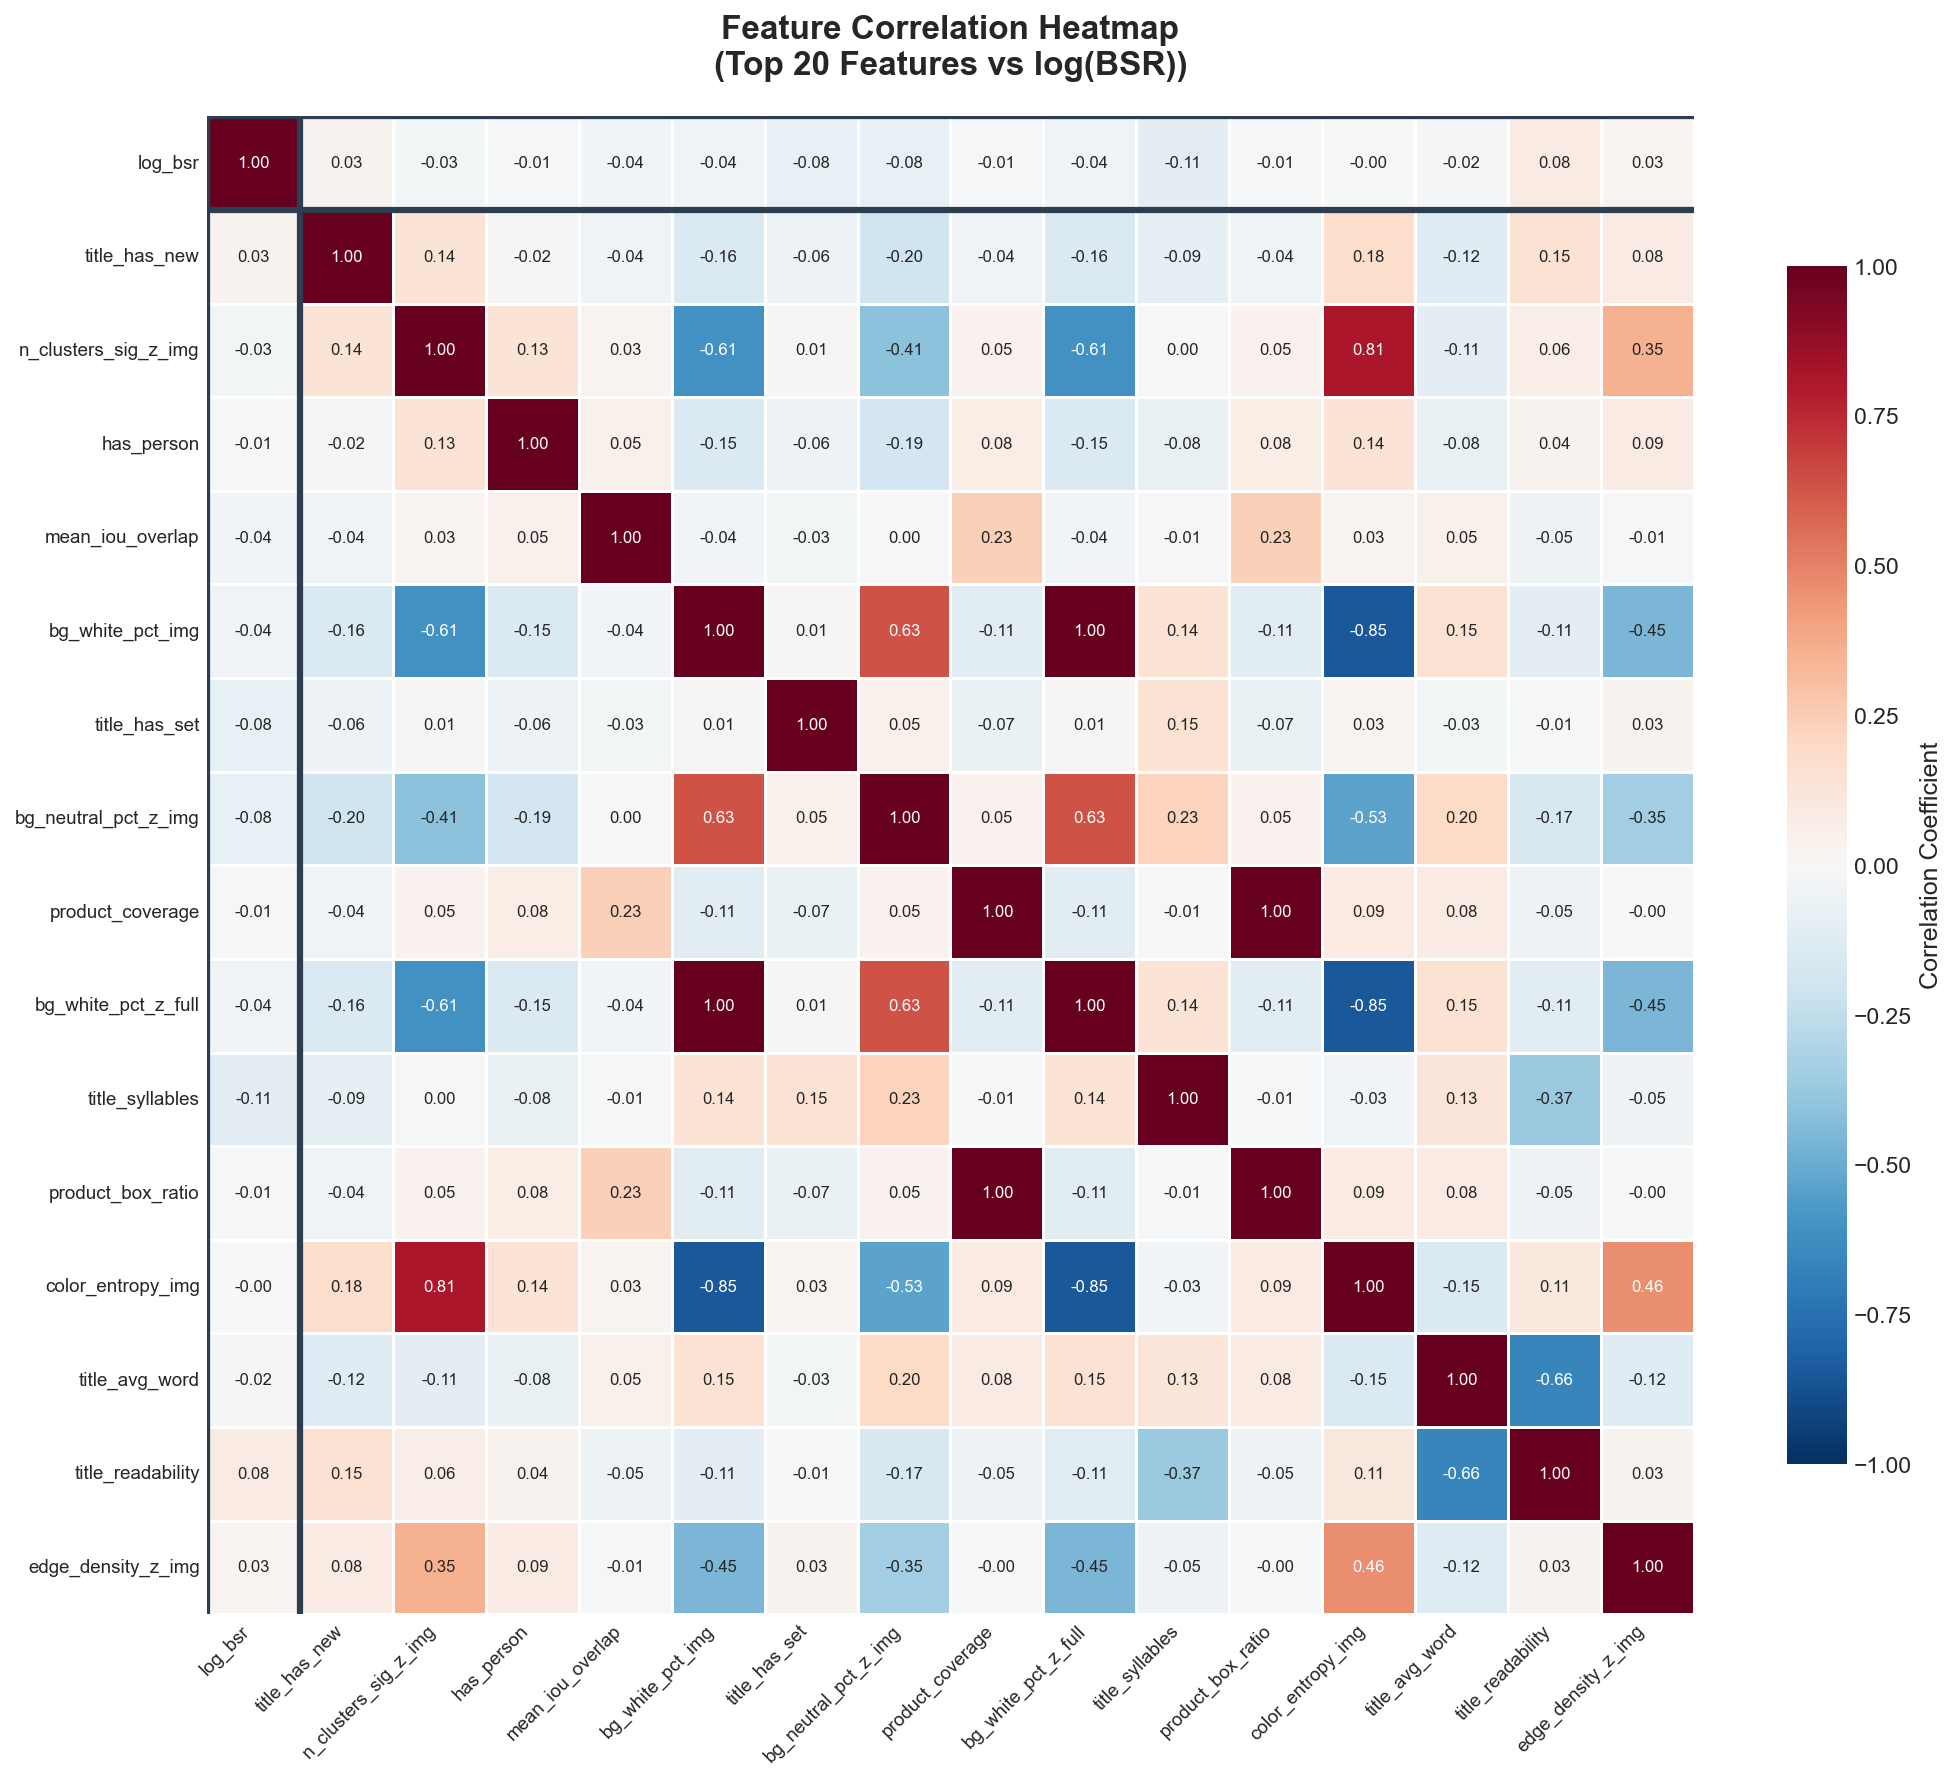

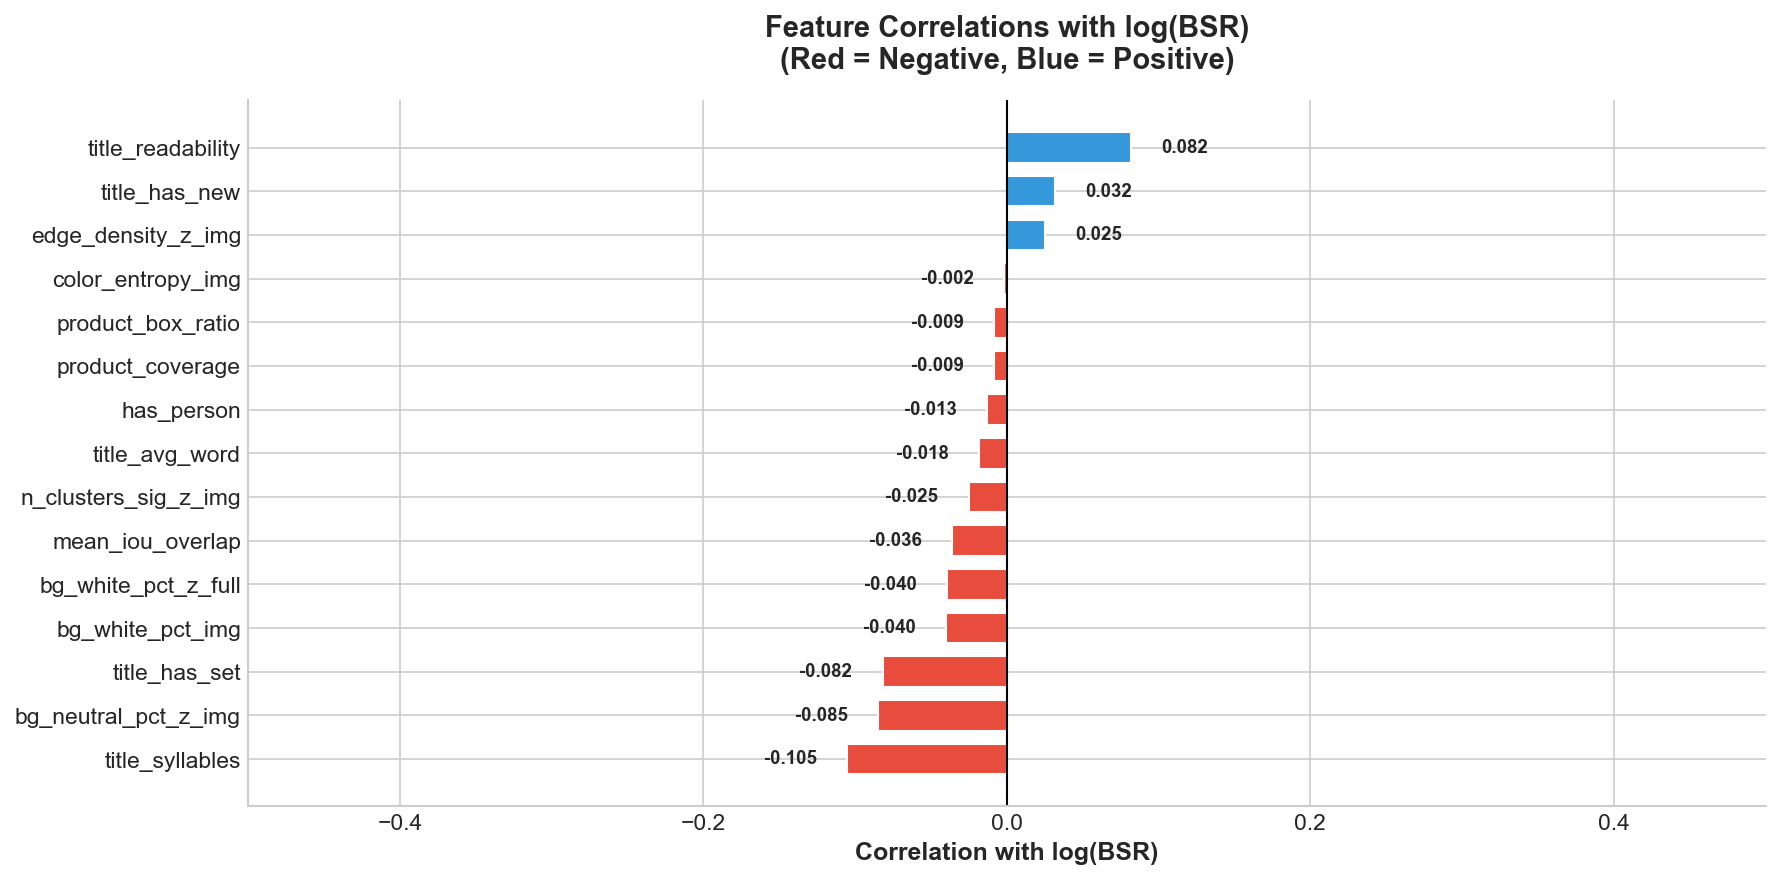


[FIGURE 5: Correlation Heatmap]

Top 5 Positive Correlations with log(BSR):
  title_readability: 0.082
  title_has_new: 0.032
  edge_density_z_img: 0.025
  color_entropy_img: -0.002
  product_coverage: -0.009

Top 5 Negative Correlations with log(BSR):
  title_syllables: -0.105
  bg_neutral_pct_z_img: -0.085
  title_has_set: -0.082
  bg_white_pct_img: -0.040
  bg_white_pct_z_full: -0.040


In [ ]:
# ============================================================
# FIGURE 5: Correlation Heatmap (Top 20 Features vs log(BSR))
# ============================================================

# Get feature importances first (needed for top features)
imp_reg = reg.get_booster().get_score(importance_type='gain')
fi_df = pd.DataFrame({
    "feature": list(imp_reg.keys()),
    "importance": list(imp_reg.values())
}).sort_values("importance", ascending=False)

# Prepare data with log BSR
corr_df = df_ranked.copy()
corr_df['log_bsr'] = np.log1p(corr_df['bsr_best_full'])

# Get top 20 features by importance
top_20_features = fi_df.head(20)['feature'].tolist()
available_features = [f for f in top_20_features if f in corr_df.columns or f in X_reg.columns]

# Build correlation matrix
corr_data = pd.DataFrame()
corr_data['log_bsr'] = corr_df['log_bsr'].values

for feat in available_features[:20]:
    if feat in X_reg.columns:
        corr_data[feat] = X_reg[feat].values
    elif feat in corr_df.columns:
        corr_data[feat] = corr_df[feat].values

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Create the heatmap
fig, ax = plt.subplots(figsize=(14, 12))

hm = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
    annot_kws={'fontsize': 8},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap\n(Top 20 Features vs log(BSR))', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
ax.axhline(y=0, color='#2C3E50', linewidth=3)
ax.axhline(y=1, color='#2C3E50', linewidth=3)
ax.axvline(x=0, color='#2C3E50', linewidth=3)
ax.axvline(x=1, color='#2C3E50', linewidth=3)
plt.tight_layout()
plt.show()

# Also show just correlations with log_bsr as a bar chart
fig2, ax2 = plt.subplots(figsize=(12, 6))
bsr_corrs = corr_matrix['log_bsr'].drop('log_bsr').sort_values()
colors = ['#E74C3C' if x < 0 else '#3498DB' for x in bsr_corrs.values]
bars = ax2.barh(bsr_corrs.index, bsr_corrs.values, color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, bsr_corrs.values):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_xlabel('Correlation with log(BSR)', fontsize=12, fontweight='bold')
ax2.set_title('Feature Correlations with log(BSR)\n(Red = Negative, Blue = Positive)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlim(-0.5, 0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 5: Correlation Heatmap]")
print("="*60)
print("\nTop 5 Positive Correlations with log(BSR):")
for feat, val in bsr_corrs.nlargest(5).items():
    print(f"  {feat}: {val:.3f}")
print("\nTop 5 Negative Correlations with log(BSR):")
for feat, val in bsr_corrs.nsmallest(5).items():
    print(f"  {feat}: {val:.3f}")

---
# 📈 FIGURE 6: BSR Distribution (Raw vs Log-Transformed)
---

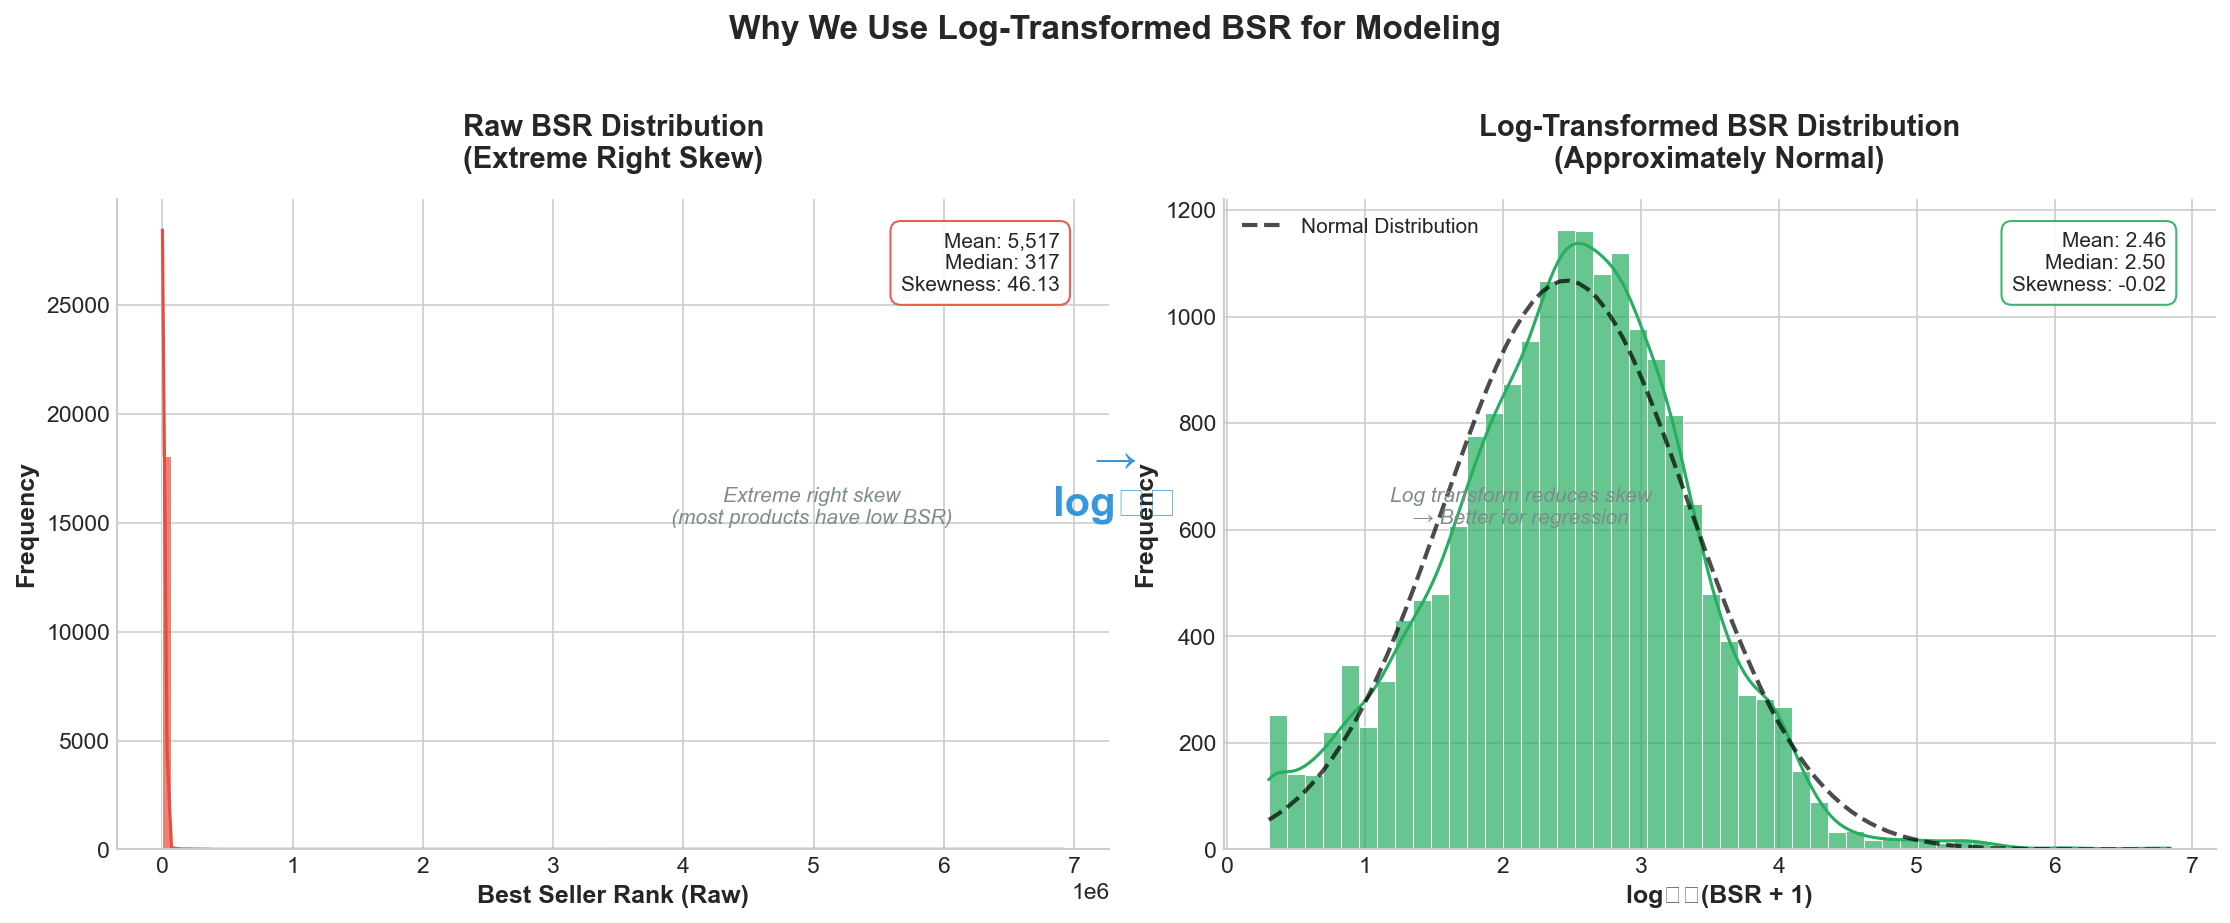


[FIGURE 6: BSR Distribution - Raw vs Log-Transformed]

Raw BSR Statistics:
  Mean: 5,517
  Median: 317
  Skewness: 46.13
  Range: 1 - 6,922,922

Log10(BSR) Statistics:
  Mean: 2.46
  Median: 2.50
  Skewness: -0.02

Skewness reduced by: 46.11


In [ ]:
# ============================================================
# FIGURE 6: BSR Distribution (Raw vs Log-Transformed)
# ============================================================

# Get BSR values
bsr_values = df_ranked['bsr_best_full'].dropna()
log_bsr_values = np.log10(bsr_values + 1)

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Raw BSR distribution
ax1 = axes[0]
sns.histplot(bsr_values, bins=100, kde=True, ax=ax1, color='#E74C3C', alpha=0.7, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Best Seller Rank (Raw)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Raw BSR Distribution\n(Extreme Right Skew)', fontsize=14, fontweight='bold', pad=15)
mean_raw = bsr_values.mean()
median_raw = bsr_values.median()
skew_raw = bsr_values.skew()
stats_text = f'Mean: {mean_raw:,.0f}\nMedian: {median_raw:,.0f}\nSkewness: {skew_raw:.2f}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#E74C3C', alpha=0.9))
ax1.annotate('Extreme right skew\n(most products have low BSR)', xy=(0.7, 0.5), xycoords='axes fraction',
             fontsize=10, style='italic', color='#7F8C8D', ha='center')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Log10 BSR distribution
ax2 = axes[1]
sns.histplot(log_bsr_values, bins=50, kde=True, ax=ax2, color='#27AE60', alpha=0.7, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('log₁₀(BSR + 1)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Log-Transformed BSR Distribution\n(Approximately Normal)', fontsize=14, fontweight='bold', pad=15)
mean_log = log_bsr_values.mean()
median_log = log_bsr_values.median()
skew_log = log_bsr_values.skew()
stats_text2 = f'Mean: {mean_log:.2f}\nMedian: {median_log:.2f}\nSkewness: {skew_log:.2f}'
ax2.text(0.95, 0.95, stats_text2, transform=ax2.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#27AE60', alpha=0.9))
x_range = np.linspace(log_bsr_values.min(), log_bsr_values.max(), 100)
normal_fit = stats.norm.pdf(x_range, mean_log, log_bsr_values.std())
scale_factor = len(log_bsr_values) * (log_bsr_values.max() - log_bsr_values.min()) / 50
ax2.plot(x_range, normal_fit * scale_factor, 'k--', linewidth=2, label='Normal Distribution', alpha=0.7)
ax2.legend(loc='upper left', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.annotate('Log transform reduces skew\n→ Better for regression', xy=(0.3, 0.5), xycoords='axes fraction',
             fontsize=10, style='italic', color='#7F8C8D', ha='center')
plt.suptitle('Why We Use Log-Transformed BSR for Modeling', fontsize=16, fontweight='bold', y=1.02)
fig.text(0.5, 0.5, '→\nlog₁₀', fontsize=20, fontweight='bold', ha='center', va='center', color='#3498DB')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 6: BSR Distribution - Raw vs Log-Transformed]")
print("="*60)
print(f"\nRaw BSR Statistics:")
print(f"  Mean: {mean_raw:,.0f}")
print(f"  Median: {median_raw:,.0f}")
print(f"  Skewness: {skew_raw:.2f}")
print(f"  Range: {bsr_values.min():,.0f} - {bsr_values.max():,.0f}")
print(f"\nLog10(BSR) Statistics:")
print(f"  Mean: {mean_log:.2f}")
print(f"  Median: {median_log:.2f}")
print(f"  Skewness: {skew_log:.2f}")
print(f"\nSkewness reduced by: {abs(skew_raw) - abs(skew_log):.2f}")

---
# 📈 FIGURE 7: BSR Distribution by Image Count Bins
---

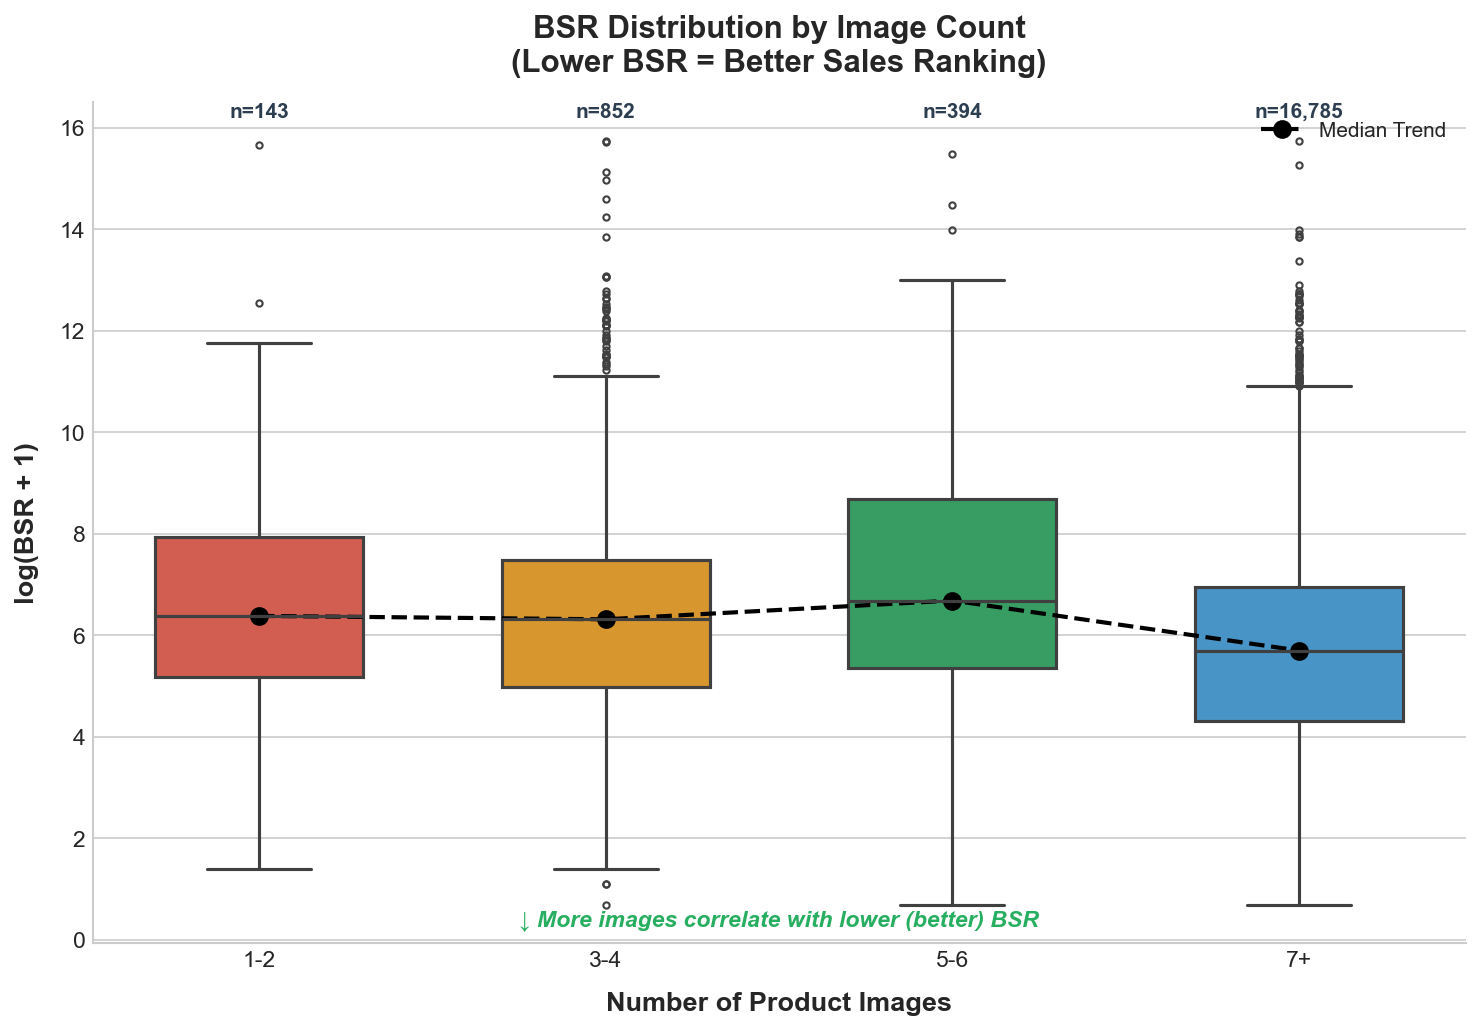


[FIGURE 7: BSR Distribution by Image Count Bins]


In [ ]:
# ============================================================
# FIGURE 7: BSR Distribution by Image Count Bins
# ============================================================

# Prepare data with image count
plot_df = df_ranked.copy()

# Get image_count from image_df
if 'image_count' in image_df.columns:
    img_count_df = image_df[['asin', 'image_count']].drop_duplicates()
    plot_df = plot_df.merge(img_count_df, on='asin', how='left')
else:
    img_cols = [c for c in final_df.columns if 'image_count' in c.lower()]
    if img_cols:
        plot_df['image_count'] = df_ranked[img_cols[0]].values if img_cols[0] in df_ranked.columns else 3
    else:
        if 'image_count' in X_reg.columns:
            plot_df['image_count'] = X_reg['image_count'].values
        else:
            plot_df['image_count'] = 3

# Create bins
def create_image_bins(x):
    if pd.isna(x) or x <= 0:
        return '1-2'
    elif x <= 2:
        return '1-2'
    elif x <= 4:
        return '3-4'
    elif x <= 6:
        return '5-6'
    else:
        return '7+'

plot_df['image_bin'] = plot_df['image_count'].apply(create_image_bins)
plot_df['log_bsr'] = np.log1p(plot_df['bsr_best_full'])

# Create the figure
fig, ax = plt.subplots(figsize=(10, 7))
order = ['1-2', '3-4', '5-6', '7+']
colors = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB']

box = sns.boxplot(data=plot_df, x='image_bin', y='log_bsr', order=order, palette=colors, ax=ax, width=0.6, linewidth=1.5, fliersize=3)

# Add sample sizes
for i, bin_name in enumerate(order):
    n = len(plot_df[plot_df['image_bin'] == bin_name])
    ax.annotate(f'n={n:,}', xy=(i, ax.get_ylim()[1] - 0.3), ha='center', fontsize=10, color='#2C3E50', fontweight='bold')

# Add median trend line
medians = [plot_df[plot_df['image_bin'] == b]['log_bsr'].median() for b in order]
ax.plot(range(len(order)), medians, 'ko--', linewidth=2, markersize=8, label='Median Trend')

ax.set_xlabel('Number of Product Images', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('log(BSR + 1)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('BSR Distribution by Image Count\n(Lower BSR = Better Sales Ranking)', fontsize=15, fontweight='bold', pad=15)
ax.annotate('↓ More images correlate with lower (better) BSR', xy=(0.5, 0.02), xycoords='axes fraction', ha='center',
            fontsize=11, style='italic', color='#27AE60', fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 7: BSR Distribution by Image Count Bins]")
print("="*60)

---
# 📈 FIGURE 8: Confusion Matrix Heatmap
---


# ============================================================
# FIGURE 8: Confusion Matrix Heatmap for XGBoost Classifier
# ============================================================

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_clf)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create labels with both counts and percentages
labels = np.array([[f'{val:,}\n({pct:.1f}%)' for val, pct in zip(row_vals, row_pcts)] 
                   for row_vals, row_pcts in zip(cm, cm_percent)])

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['Predicted:\nUnranked (0)', 'Predicted:\nRanked (1)'],
            yticklabels=['Actual:\nUnranked (0)', 'Actual:\nRanked (1)'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            linewidths=3, linecolor='white',
            cbar_kws={'label': 'Count', 'shrink': 0.8},
            ax=ax)

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('True Label', fontsize=14, fontweight='bold', labelpad=15)
ax.set_title('XGBoost Classifier: Confusion Matrix\n(Predicting Whether Product Will Have BSR Ranking)', 
             fontsize=16, fontweight='bold', pad=20)

# Add accuracy annotation
accuracy = accuracy_score(y_test, y_pred_clf)
precision = precision_score(y_test, y_pred_clf)
recall = recall_score(y_test, y_pred_clf)
f1 = f1_score(y_test, y_pred_clf)

metrics_text = f'Accuracy: {accuracy:.1%}\nPrecision: {precision:.1%}\nRecall: {recall:.1%}\nF1 Score: {f1:.1%}'
ax.text(1.35, 0.5, metrics_text, transform=ax.transAxes, fontsize=12, 
        verticalalignment='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F6F3', edgecolor='#27AE60', alpha=0.95))

ax.text(0.5, -0.12, 'True Negatives (TN)', transform=ax.transAxes, ha='left', fontsize=10, 
        color='#27AE60', fontweight='bold', style='italic')
ax.text(0.5, -0.17, 'False Positives (FP)', transform=ax.transAxes, ha='right', fontsize=10, 
        color='#E74C3C', fontweight='bold', style='italic')

plt.tight_layout()
plt.show()

# Normalized version
fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='RdYlGn', 
            xticklabels=['Predicted:\nUnranked (0)', 'Predicted:\nRanked (1)'],
            yticklabels=['Actual:\nUnranked (0)', 'Actual:\nRanked (1)'],
            annot_kws={'fontsize': 18, 'fontweight': 'bold'},
            linewidths=3, linecolor='white', vmin=0, vmax=100,
            cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
            ax=ax2)

for t in ax2.texts:
    t.set_text(t.get_text() + '%')

ax2.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=15)
ax2.set_ylabel('True Label', fontsize=14, fontweight='bold', labelpad=15)
ax2.set_title('XGBoost Classifier: Normalized Confusion Matrix\n(Row-wise Percentages)', 
              fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 8: Confusion Matrix Heatmap]")
print("="*60)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Unranked  Ranked")
print(f"Actual Unranked    {cm[0,0]:,}      {cm[0,1]:,}")
print(f"Actual Ranked      {cm[1,0]:,}     {cm[1,1]:,}")
print(f"\nMetrics:")
print(f"  True Negatives (TN): {cm[0,0]:,} ({cm_percent[0,0]:.1f}%)")
print(f"  False Positives (FP): {cm[0,1]:,} ({cm_percent[0,1]:.1f}%)")
print(f"  False Negatives (FN): {cm[1,0]:,} ({cm_percent[1,0]:.1f}%)")
print(f"  True Positives (TP): {cm[1,1]:,} ({cm_percent[1,1]:.1f}%)")

---
# 📈 FIGURE 9: Actual vs Predicted log(BSR) Scatter Plot
---

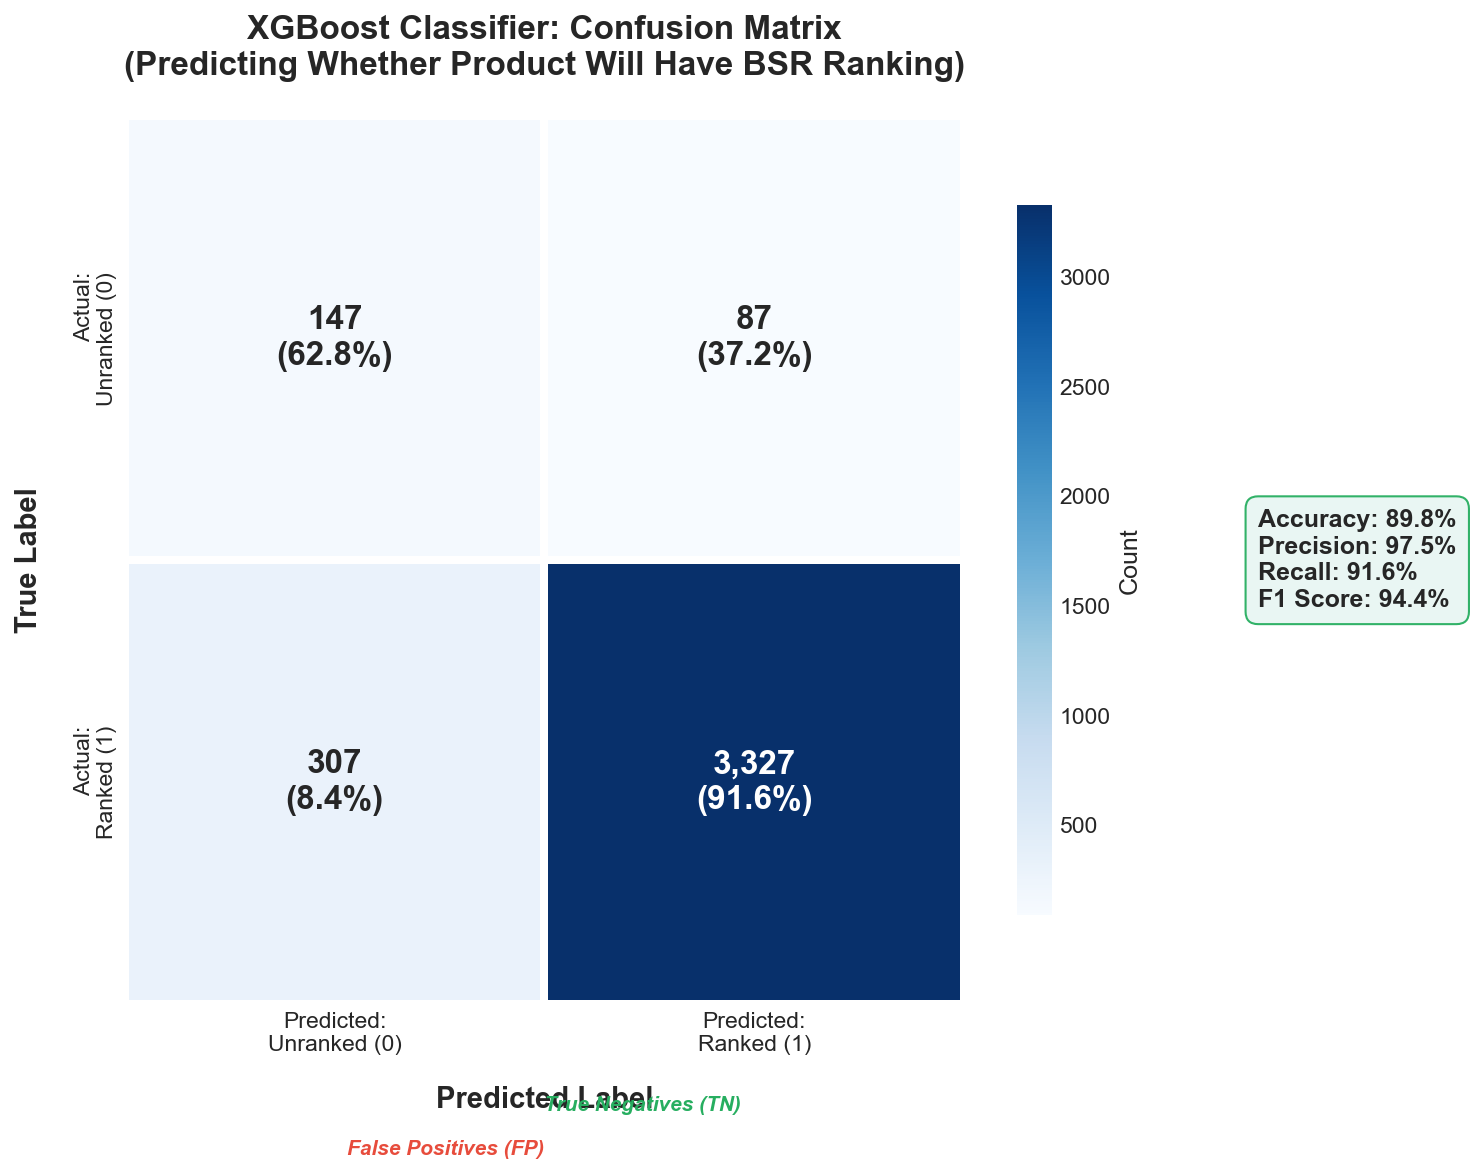

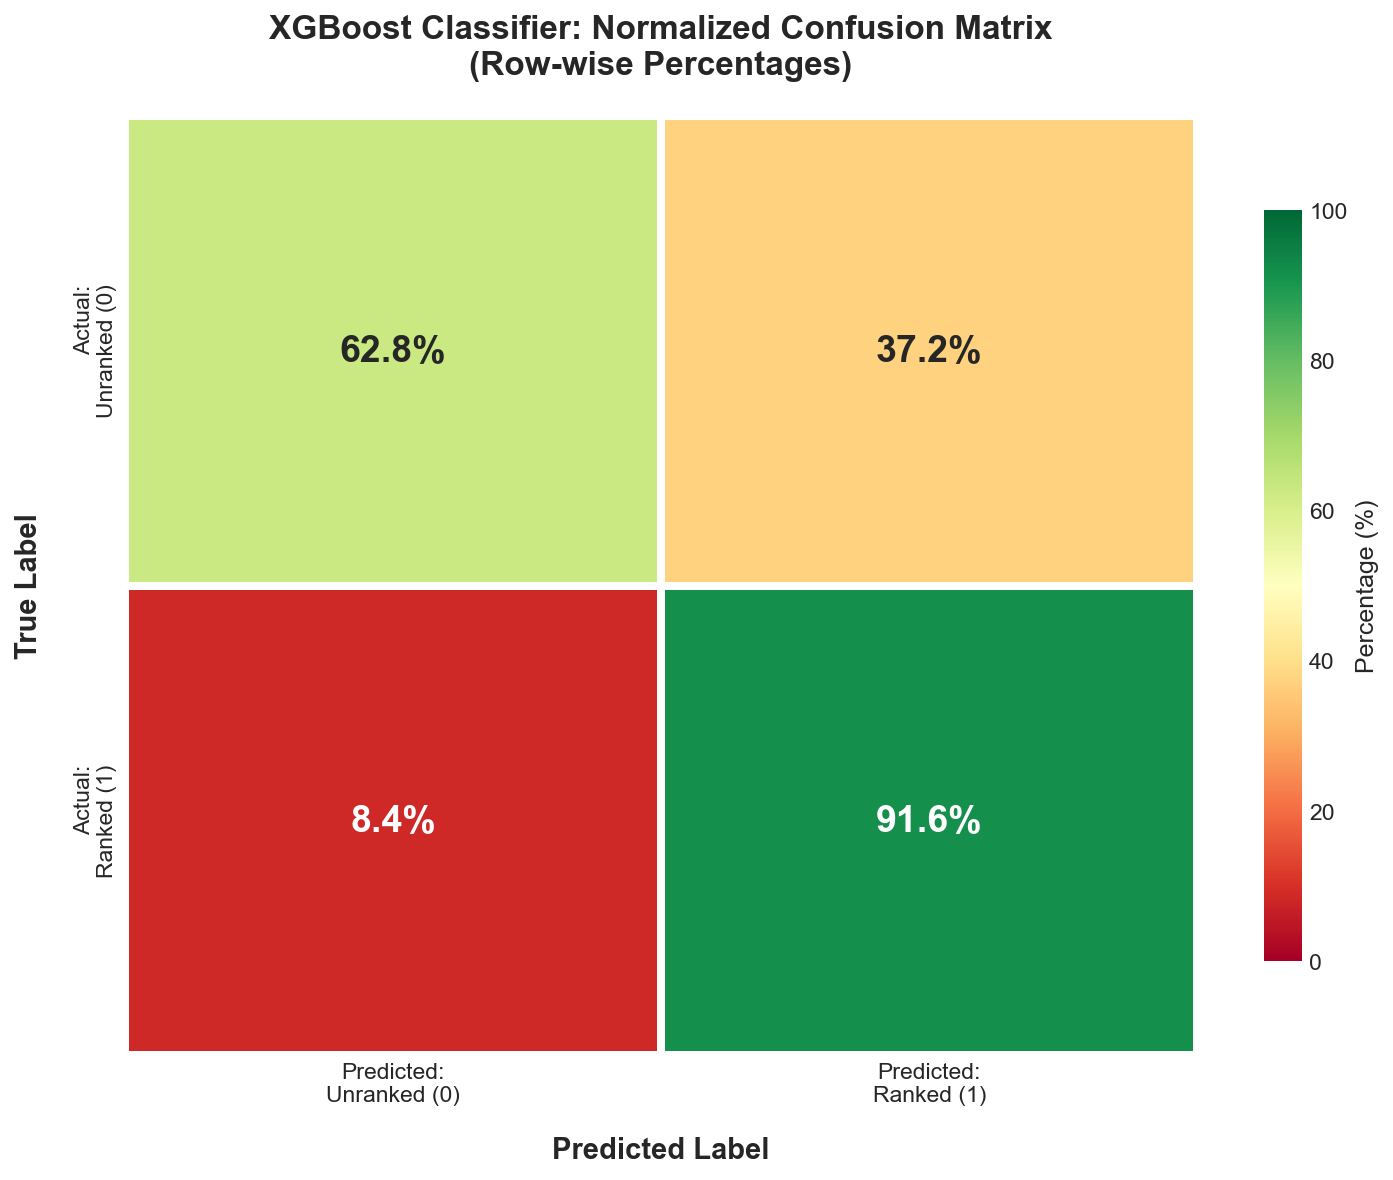


[FIGURE 8: Confusion Matrix Heatmap]

Confusion Matrix:
                    Predicted
                 Unranked  Ranked
Actual Unranked    147      87
Actual Ranked      307     3,327

Metrics:
  True Negatives (TN): 147 (62.8%)
  False Positives (FP): 87 (37.2%)
  False Negatives (FN): 307 (8.4%)
  True Positives (TP): 3,327 (91.6%)


In [ ]:
# ============================================================
# FIGURE 9: Actual vs Predicted log(BSR) Scatter Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 9))

# Create hexbin for density visualization
hb = ax.hexbin(y_reg_test, y_pred_reg, gridsize=40, cmap='YlOrRd', mincnt=1, alpha=0.9)
cb = plt.colorbar(hb, ax=ax, label='Point Density', shrink=0.8)
cb.ax.tick_params(labelsize=10)

# Add diagonal reference line
min_val = min(y_reg_test.min(), y_pred_reg.min())
max_val = max(y_reg_test.max(), y_pred_reg.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2.5, 
        label='Perfect Prediction', alpha=0.8)

# Calculate metrics
r2 = r2_score(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))

# Add R² and RMSE annotation box
textstr = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}'
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#E74C3C', 
             alpha=0.95, linewidth=2)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14, 
        verticalalignment='top', bbox=props, fontweight='bold')

ax.set_xlabel('Actual log(BSR + 1)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Predicted log(BSR + 1)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('XGBoost Regression: Actual vs. Predicted BSR\n(Log-Transformed)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

ax.set_xlim(min_val - 0.5, max_val + 0.5)
ax.set_ylim(min_val - 0.5, max_val + 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 9: Actual vs Predicted log(BSR) with Density Gradient]")
print("="*60)

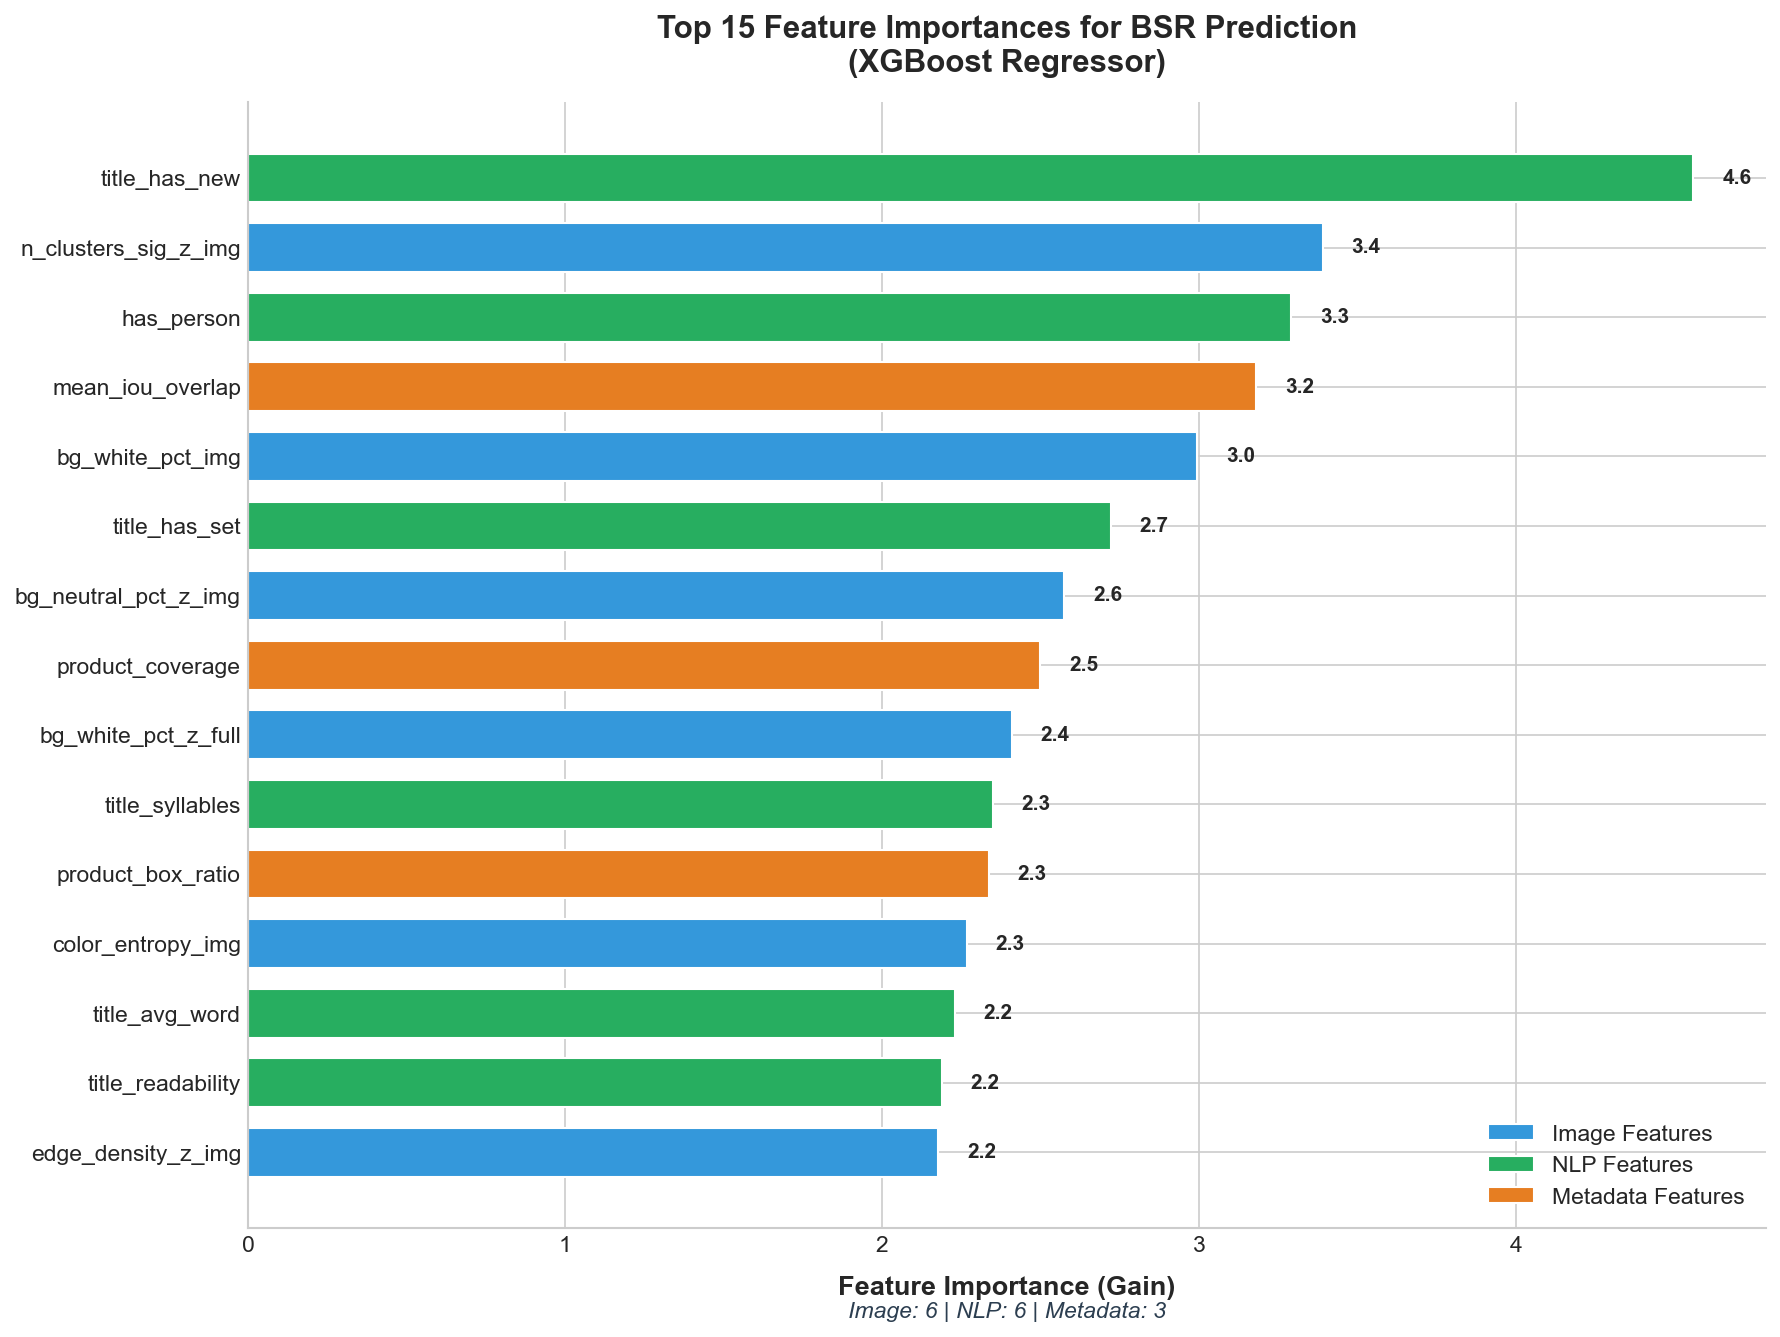


[FIGURE 10: Feature Importances by Category]
  Image features in top 15: 6
  NLP features in top 15: 6
  Metadata features in top 15: 3


In [ ]:
---
# 📈 FIGURE 10: Feature Importances by Category
---

# ============================================================
# FIGURE 10: Feature Importances by Category (Color-Coded)
# ============================================================

# Get feature importances from regressor (if not already done)
if 'fi_df' not in locals():
    imp_reg = reg.get_booster().get_score(importance_type='gain')
    fi_df = pd.DataFrame({
        "feature": list(imp_reg.keys()),
        "importance": list(imp_reg.values())
    }).sort_values("importance", ascending=False).head(15)

# Categorize features
def categorize_feature(name):
    image_keywords = ['bg_', 'edge', 'color', 'cluster', 'clutter', 'image', 'entropy', 
                      'sharpness', 'contrast', 'saturation', 'exposure', 'noise', 'laplacian']
    nlp_keywords = ['title', 'readability', 'syllable', 'word', 'char', 'has_', 'text']
    name_lower = name.lower()
    if any(kw in name_lower for kw in image_keywords):
        return 'Image'
    elif any(kw in name_lower for kw in nlp_keywords):
        return 'NLP'
    else:
        return 'Metadata'

fi_df['category'] = fi_df['feature'].apply(categorize_feature)
color_map = {'Image': '#3498DB', 'NLP': '#27AE60', 'Metadata': '#E67E22'}
fi_df['color'] = fi_df['category'].map(color_map)

# Create the figure
fig, ax = plt.subplots(figsize=(12, 9))
fi_df_plot = fi_df.iloc[::-1]

bars = ax.barh(fi_df_plot['feature'], fi_df_plot['importance'], 
               color=fi_df_plot['color'], edgecolor='white', height=0.7, linewidth=1)

max_imp = fi_df_plot['importance'].max()
for bar, val in zip(bars, fi_df_plot['importance']):
    ax.text(bar.get_width() + max_imp * 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498DB', edgecolor='white', label='Image Features'),
    Patch(facecolor='#27AE60', edgecolor='white', label='NLP Features'),
    Patch(facecolor='#E67E22', edgecolor='white', label='Metadata Features')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.95)

ax.set_xlabel('Feature Importance (Gain)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('')
ax.set_title('Top 15 Feature Importances for BSR Prediction\n(XGBoost Regressor)', 
             fontsize=15, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cat_counts = fi_df['category'].value_counts()
info_text = f"Image: {cat_counts.get('Image', 0)} | NLP: {cat_counts.get('NLP', 0)} | Metadata: {cat_counts.get('Metadata', 0)}"
ax.annotate(info_text, xy=(0.5, -0.08), xycoords='axes fraction', ha='center', 
            fontsize=11, style='italic', color='#2C3E50')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 10: Feature Importances by Category]")
print(f"  Image features in top 15: {cat_counts.get('Image', 0)}")
print(f"  NLP features in top 15: {cat_counts.get('NLP', 0)}")
print(f"  Metadata features in top 15: {cat_counts.get('Metadata', 0)}")
print("="*60)

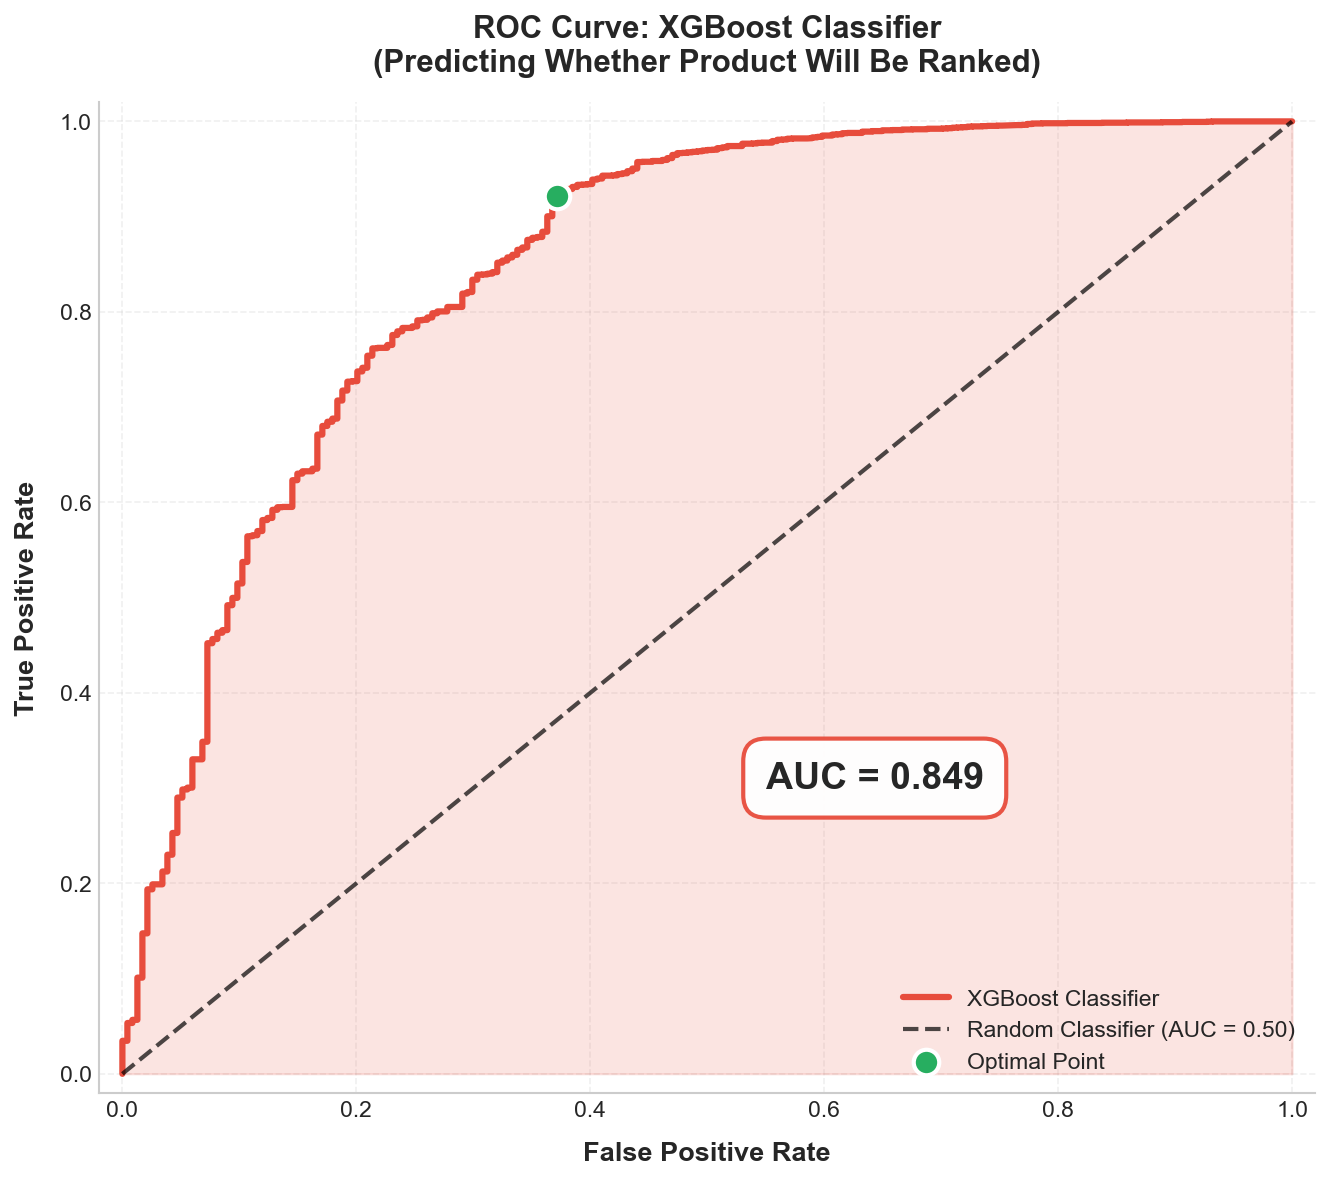


[FIGURE 11: ROC Curve with AUC = 0.849]


In [ ]:
---
# 📈 FIGURE 11: ROC Curve with AUC Annotation
---

# ============================================================
# FIGURE 11: ROC Curve for XGBoost Classifier
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_clf_proba)
auc_score = roc_auc_score(y_test, y_pred_clf_proba)

fig, ax = plt.subplots(figsize=(9, 8))

ax.plot(fpr, tpr, color='#E74C3C', linewidth=3, label=f'XGBoost Classifier')
ax.fill_between(fpr, tpr, alpha=0.15, color='#E74C3C')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.50)', alpha=0.7)

ax.annotate(f'AUC = {auc_score:.3f}', xy=(0.55, 0.30), fontsize=18, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                     edgecolor='#E74C3C', alpha=0.95, linewidth=2))

optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], c='#27AE60', s=150, zorder=5, 
           edgecolor='white', linewidth=2, label=f'Optimal Point')

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('ROC Curve: XGBoost Classifier\n(Predicting Whether Product Will Be Ranked)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"[FIGURE 11: ROC Curve with AUC = {auc_score:.3f}]")
print("="*60)

---
# 📈 FIGURE 12: Residuals Distribution
---

In [ ]:
# ============================================================
# FIGURE 12: Residuals Distribution (Histogram + Normal Curve)
# ============================================================

# Calculate residuals
residuals = y_reg_test.values - y_pred_reg

# Create the figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot histogram of residuals
n, bins, patches = ax.hist(residuals, bins=50, density=True, alpha=0.7, 
                            color='#3498DB', edgecolor='white', linewidth=0.8,
                            label='Residuals Distribution')

# Fit and overlay normal distribution
mu = residuals.mean()
sigma = residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_curve = stats.norm.pdf(x, mu, sigma)

ax.plot(x, normal_curve, 'r-', linewidth=3, 
        label=f'Normal Distribution\n(μ={mu:.3f}, σ={sigma:.3f})')

ax.axvline(x=0, color='#2C3E50', linestyle='--', linewidth=2, 
           label='Perfect Prediction (residual=0)')

ax.axvspan(-sigma, sigma, alpha=0.15, color='#27AE60', 
           label=f'±1 Std Dev ({stats.norm.cdf(1) - stats.norm.cdf(-1):.1%} of data)')

# Perform normality test
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

stats_text = (f'Residual Statistics:\n'
              f'Mean: {mu:.4f}\n'
              f'Std Dev: {sigma:.3f}\n'
              f'Skewness: {skewness:.3f}\n'
              f'Kurtosis: {kurtosis:.3f}\n'
              f'Shapiro-Wilk p: {shapiro_p:.4f}')

ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                  edgecolor='#3498DB', alpha=0.95),
        fontfamily='monospace')

ax.set_xlabel('Residual (Actual - Predicted log(BSR))', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Density', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Distribution of Prediction Residuals\n(XGBoost Regressor)', 
             fontsize=16, fontweight='bold', pad=15)

ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Q-Q plot
fig2, ax2 = plt.subplots(figsize=(8, 8))
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Residuals vs Normal Distribution', fontsize=14, fontweight='bold', pad=15)
ax2.get_lines()[0].set_markerfacecolor('#3498DB')
ax2.get_lines()[0].set_markeredgecolor('white')
ax2.get_lines()[0].set_markersize(5)
ax2.get_lines()[1].set_color('#E74C3C')
ax2.get_lines()[1].set_linewidth(2)
ax2.set_xlabel('Theoretical Quantiles', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sample Quantiles', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 12: Residuals Distribution]")
print("="*60)
print(f"\nResidual Analysis:")
print(f"  Mean Residual: {mu:.4f} (should be ~0)")
print(f"  Std Dev: {sigma:.3f}")
print(f"  Skewness: {skewness:.3f} (0 = symmetric)")
print(f"  Kurtosis: {kurtosis:.3f} (0 = normal)")
print(f"  Shapiro-Wilk p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  → Residuals appear normally distributed (p > 0.05)")
else:
    print("  → Residuals deviate from normal distribution (p < 0.05)")

Running 5-fold cross-validation... (this may take 1-2 minutes)
  Fold 1: R² = 0.261, RMSE = 1.764
  Fold 2: R² = 0.274, RMSE = 1.755
  Fold 3: R² = 0.284, RMSE = 1.746
  Fold 4: R² = 0.232, RMSE = 1.759
  Fold 5: R² = 0.251, RMSE = 1.761


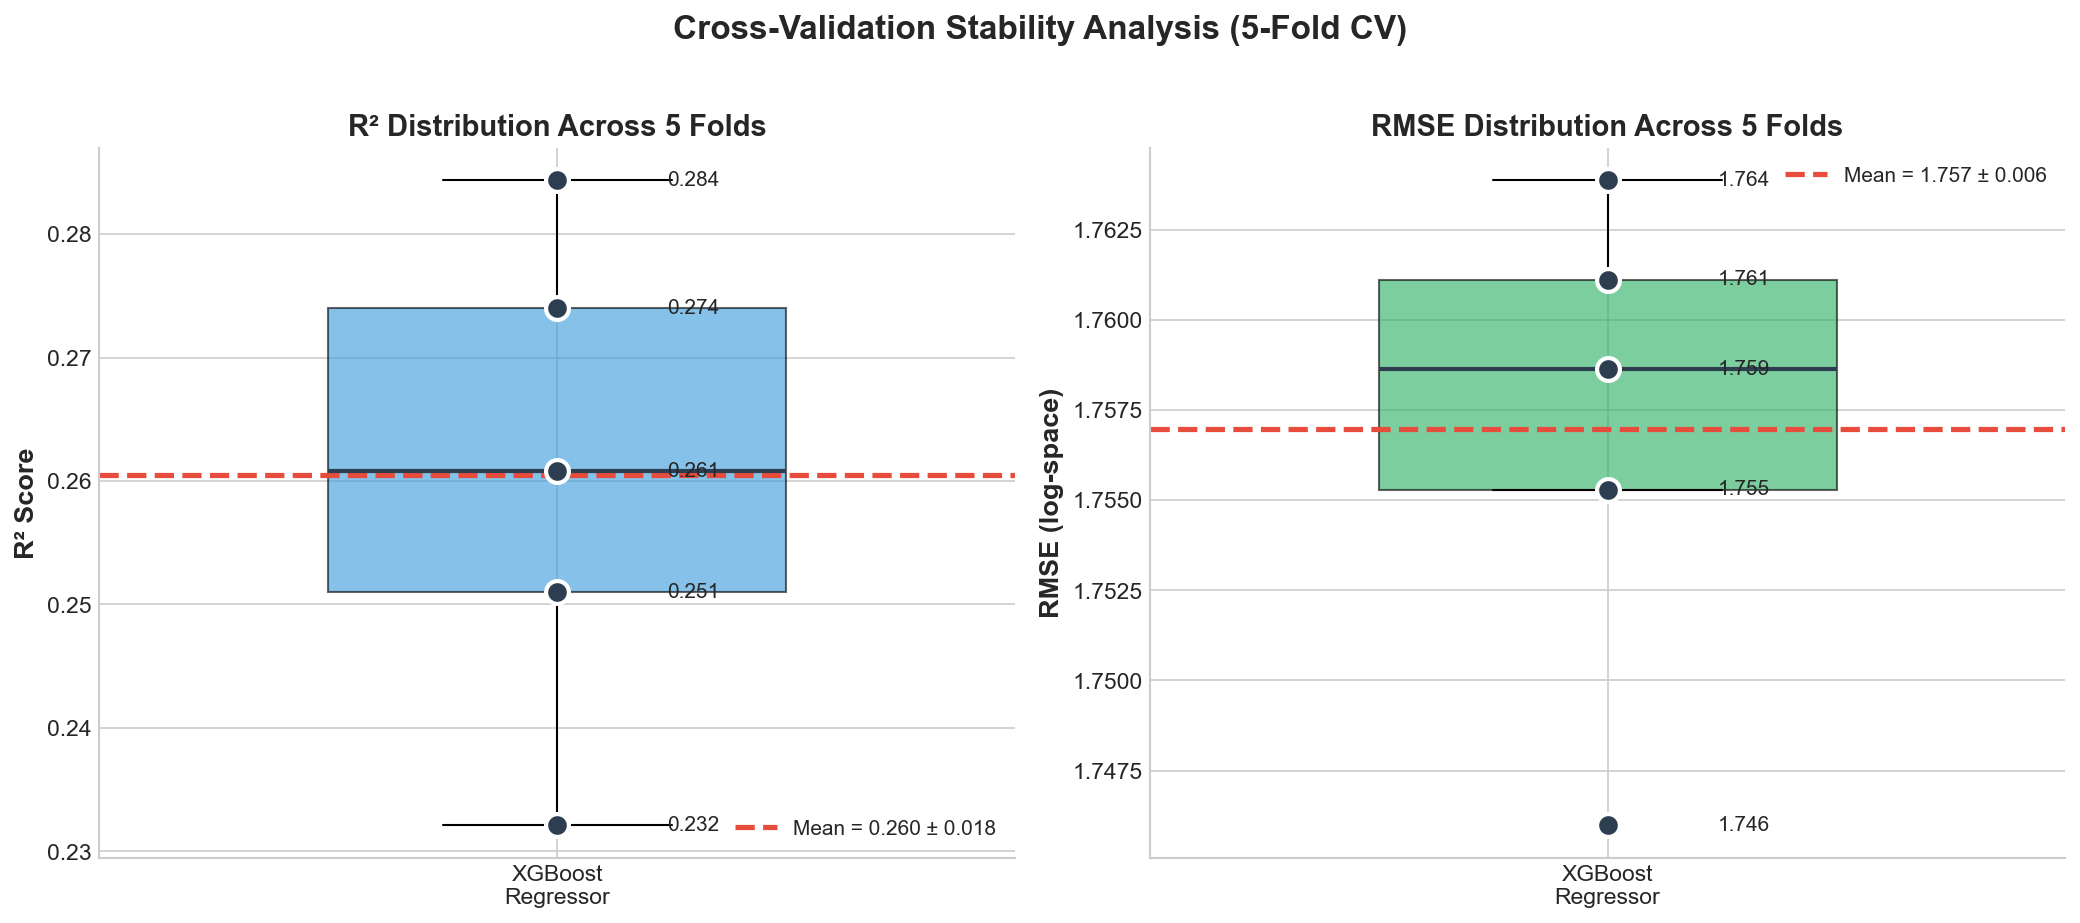


[FIGURE 13: Cross-Validation Stability]
  R² = 0.260 ± 0.018
  RMSE = 1.757 ± 0.006


In [ ]:
---
# 📈 FIGURE 13: Cross-Validation Stability Analysis
---

# ============================================================
# FIGURE 13: Cross-Validation Stability (R² and RMSE across 5 Folds)
# ============================================================

print("Running 5-fold cross-validation... (this may take 1-2 minutes)")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_reg), 1):
    X_fold_train = X_reg.iloc[train_idx]
    X_fold_val = X_reg.iloc[val_idx]
    y_fold_train = y_reg.iloc[train_idx]
    y_fold_val = y_reg.iloc[val_idx]
    
    reg_cv = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=4
    )
    reg_cv.fit(X_fold_train, y_fold_train)
    y_pred_cv = reg_cv.predict(X_fold_val)
    
    r2_cv = r2_score(y_fold_val, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y_fold_val, y_pred_cv))
    
    cv_r2_scores.append(r2_cv)
    cv_rmse_scores.append(rmse_cv)
    print(f"  Fold {fold}: R² = {r2_cv:.3f}, RMSE = {rmse_cv:.3f}")

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

box_color_r2 = '#3498DB'
box_color_rmse = '#27AE60'
point_color = '#2C3E50'
mean_color = '#E74C3C'

# R² box plot
bp1 = axes[0].boxplot(cv_r2_scores, patch_artist=True, widths=0.5)
bp1['boxes'][0].set_facecolor(box_color_r2)
bp1['boxes'][0].set_alpha(0.6)
bp1['medians'][0].set_color(point_color)
bp1['medians'][0].set_linewidth(2)
axes[0].scatter([1]*5, cv_r2_scores, color=point_color, s=120, zorder=5, edgecolor='white', linewidth=2)
for i, score in enumerate(cv_r2_scores):
    axes[0].annotate(f'{score:.3f}', xy=(1.12, score), fontsize=10, va='center')
mean_r2 = np.mean(cv_r2_scores)
std_r2 = np.std(cv_r2_scores)
axes[0].axhline(mean_r2, color=mean_color, linestyle='--', linewidth=2.5, 
                label=f'Mean = {mean_r2:.3f} ± {std_r2:.3f}')
axes[0].set_ylabel('R² Score', fontsize=13, fontweight='bold')
axes[0].set_title('R² Distribution Across 5 Folds', fontsize=14, fontweight='bold')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['XGBoost\nRegressor'], fontsize=11)
axes[0].legend(loc='lower right', fontsize=10, framealpha=0.95)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# RMSE box plot
bp2 = axes[1].boxplot(cv_rmse_scores, patch_artist=True, widths=0.5)
bp2['boxes'][0].set_facecolor(box_color_rmse)
bp2['boxes'][0].set_alpha(0.6)
bp2['medians'][0].set_color(point_color)
bp2['medians'][0].set_linewidth(2)
axes[1].scatter([1]*5, cv_rmse_scores, color=point_color, s=120, zorder=5, edgecolor='white', linewidth=2)
for i, score in enumerate(cv_rmse_scores):
    axes[1].annotate(f'{score:.3f}', xy=(1.12, score), fontsize=10, va='center')
mean_rmse = np.mean(cv_rmse_scores)
std_rmse = np.std(cv_rmse_scores)
axes[1].axhline(mean_rmse, color=mean_color, linestyle='--', linewidth=2.5, 
                label=f'Mean = {mean_rmse:.3f} ± {std_rmse:.3f}')
axes[1].set_ylabel('RMSE (log-space)', fontsize=13, fontweight='bold')
axes[1].set_title('RMSE Distribution Across 5 Folds', fontsize=14, fontweight='bold')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['XGBoost\nRegressor'], fontsize=11)
axes[1].legend(loc='upper right', fontsize=10, framealpha=0.95)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Cross-Validation Stability Analysis (5-Fold CV)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"[FIGURE 13: Cross-Validation Stability]")
print(f"  R² = {mean_r2:.3f} ± {std_r2:.3f}")
print(f"  RMSE = {mean_rmse:.3f} ± {std_rmse:.3f}")
print("="*60)

---
# 📋 APPENDIX FIGURES
---
# 📋 FIGURE 14: Complete Feature Table
---


TOTAL FEATURES: 49
  - Image Features: 29
  - NLP Features: 10
  - Metadata Features: 10


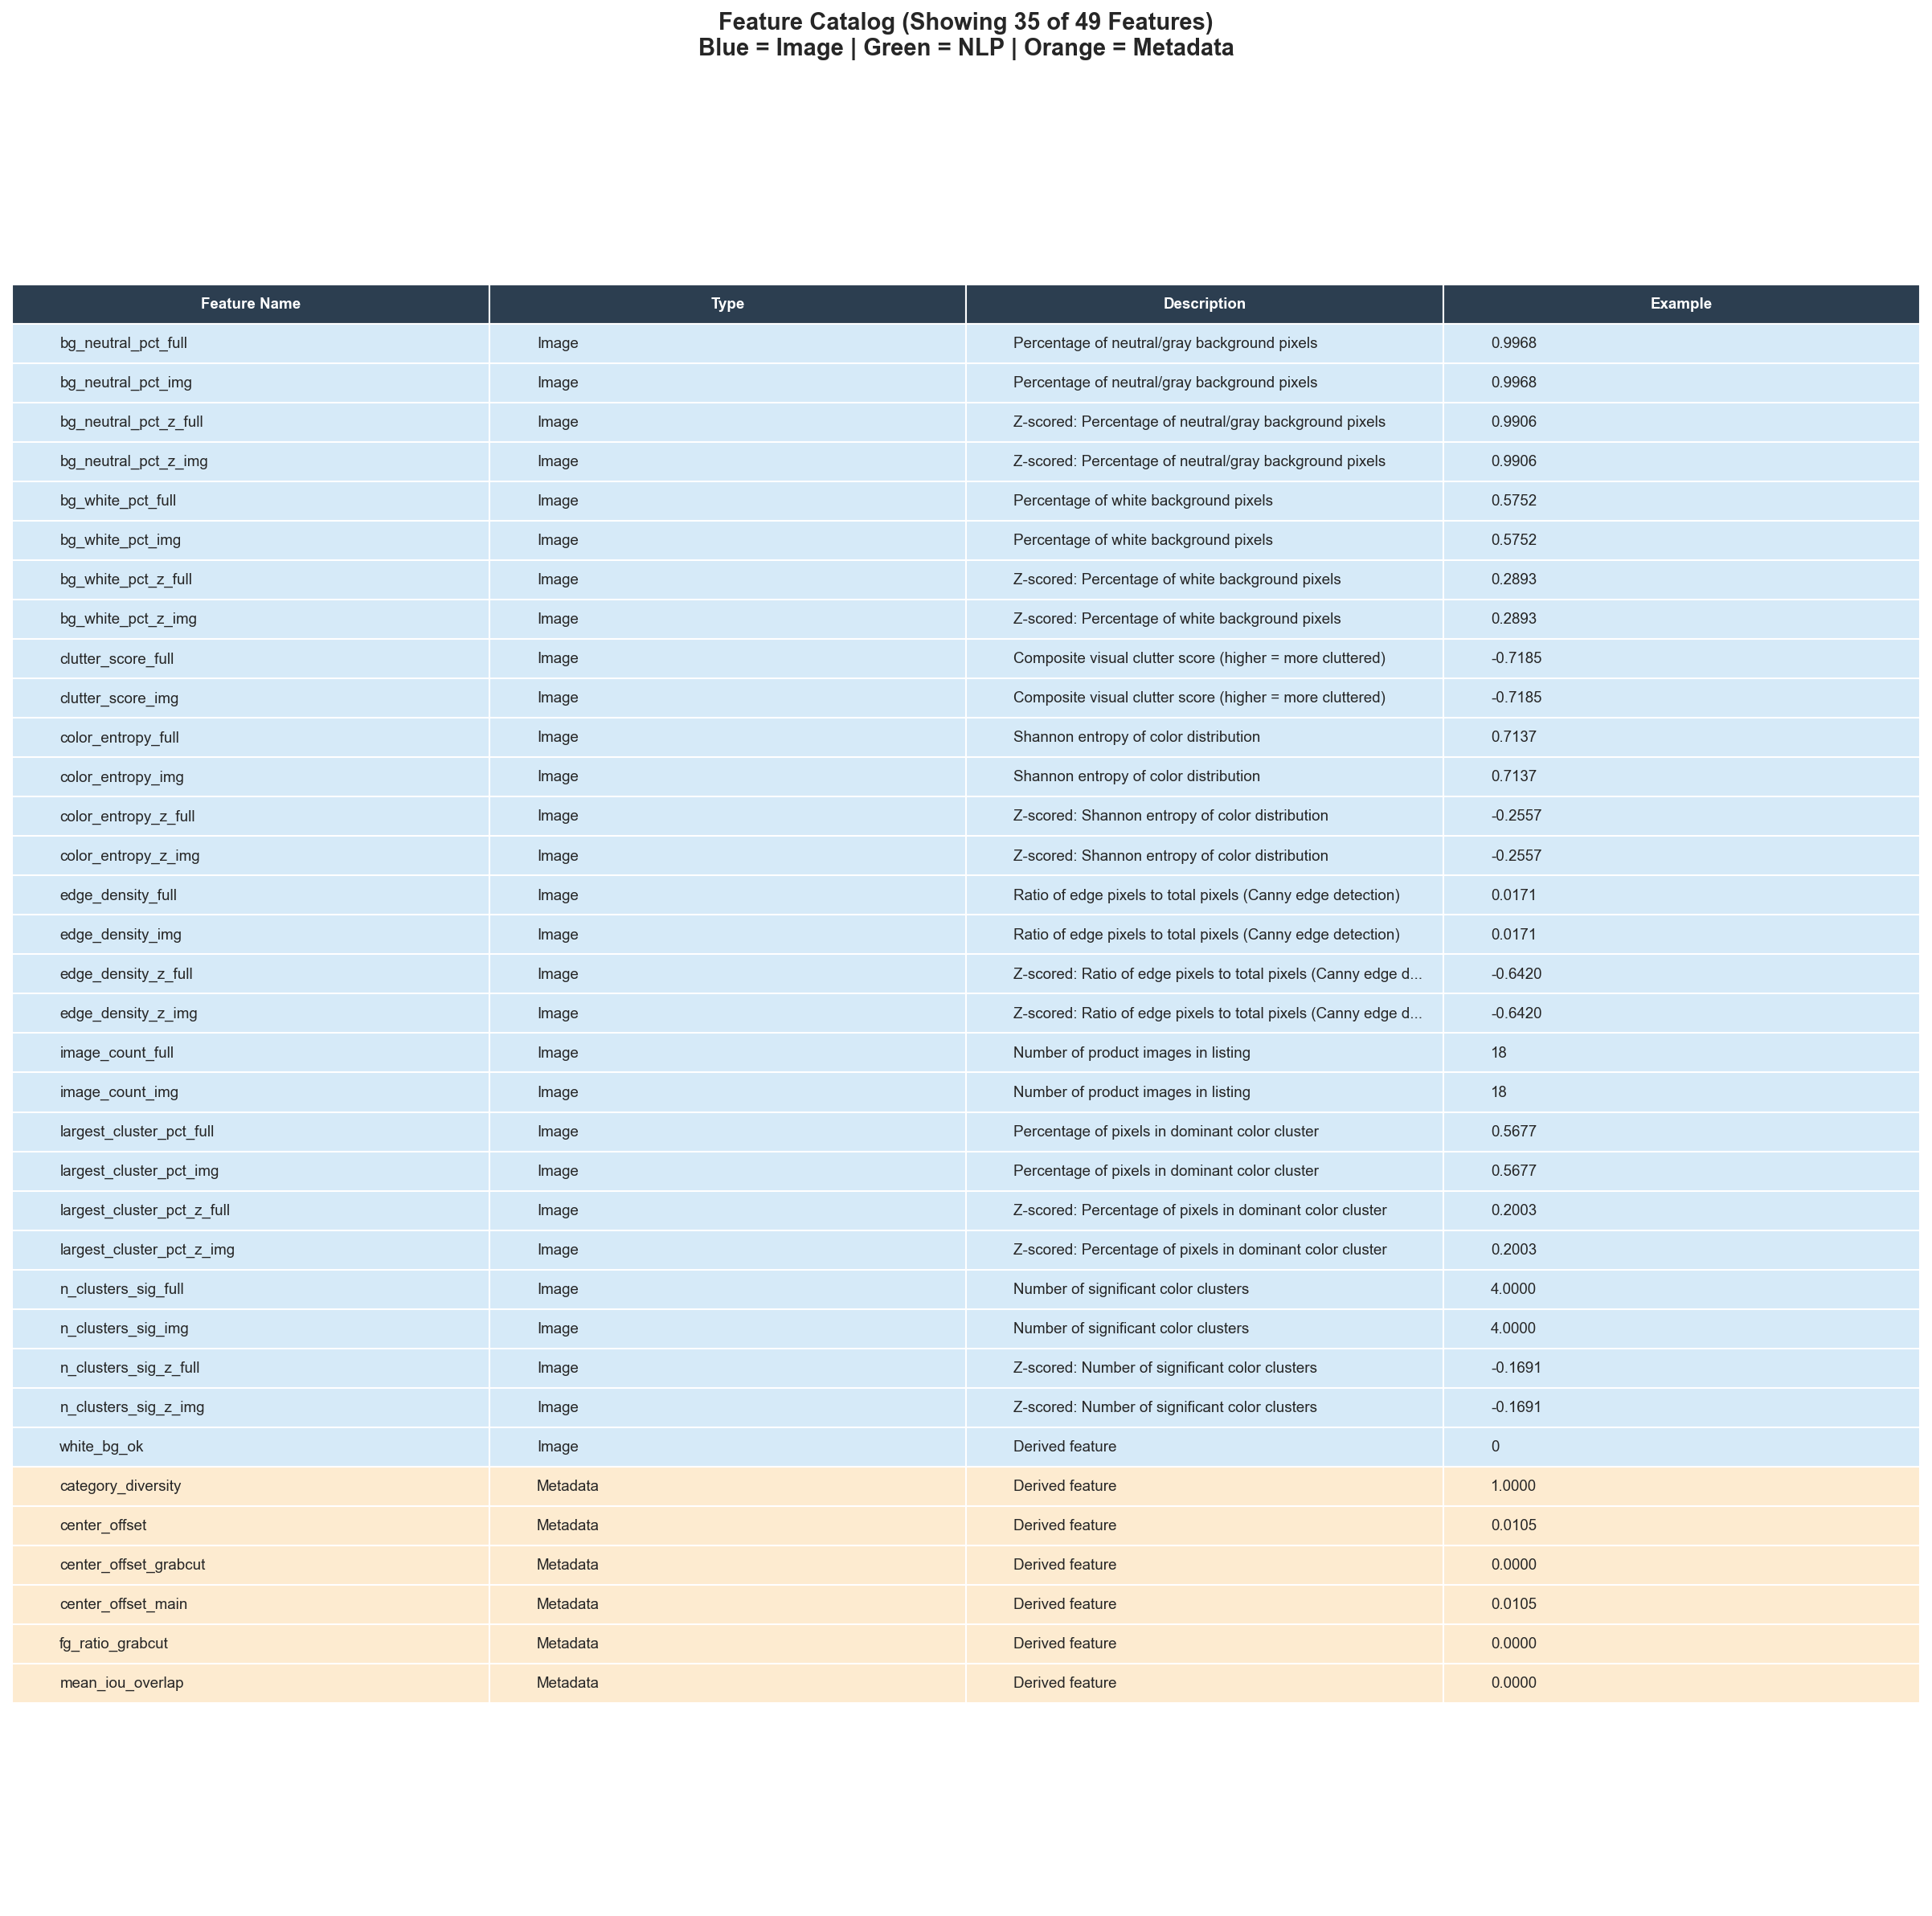


... and 14 more features (see full list below)

  [Metadata] n_objects
  [Metadata] product_box_ratio
  [Metadata] product_coverage
  [Metadata] sum_box_ratio
  [NLP] has_person
  [NLP] title_avg_word
  [NLP] title_char_len
  [NLP] title_has_new
  [NLP] title_has_premium
  [NLP] title_has_set
  [NLP] title_has_size
  [NLP] title_readability
  [NLP] title_syllables
  [NLP] title_word_len

[FIGURE 14: Complete Feature Table]


In [ ]:
# ============================================================
# FIGURE 14: Complete Feature Table
# ============================================================

feature_catalog = []
feature_descriptions = {
    'image_count': 'Number of product images in listing',
    'edge_density': 'Ratio of edge pixels to total pixels (Canny edge detection)',
    'bg_white_pct': 'Percentage of white background pixels',
    'bg_neutral_pct': 'Percentage of neutral/gray background pixels',
    'color_entropy': 'Shannon entropy of color distribution',
    'largest_cluster_pct': 'Percentage of pixels in dominant color cluster',
    'clutter_score': 'Composite visual clutter score (higher = more cluttered)',
    'title_char_len': 'Total character count of product title',
    'title_word_len': 'Total word count of product title',
    'title_avg_word': 'Average word length in title (chars/words)',
    'title_readability': 'Flesch Reading Ease score (0-100)',
    'title_syllables': 'Total syllable count in title',
    'title_has_premium': 'Binary: title contains premium/luxury/pro',
    'title_has_set': 'Binary: title contains set/bundle/pack',
    'title_has_new': 'Binary: title contains new/latest/202X',
    'title_has_size': 'Binary: title contains size indicators',
    'n_clusters_sig': 'Number of significant color clusters',
    'has_aplus': 'Binary: product has A+ content',
    'has_brand_story': 'Binary: product has brand story',
}

for col in X.columns:
    col_lower = col.lower()
    if any(kw in col_lower for kw in ['bg_', 'edge', 'color', 'cluster', 'clutter', 'image', 'entropy', 
                                       'sharpness', 'contrast', 'saturation', 'exposure', 'noise', 'laplacian']):
        cat = 'Image'
    elif any(kw in col_lower for kw in ['title', 'readability', 'syllable', 'word', 'char', 'has_', 'text']):
        cat = 'NLP'
    else:
        cat = 'Metadata'
    
    base_col = col.replace('_z', '').replace('_full', '').replace('_img', '')
    desc = feature_descriptions.get(base_col, feature_descriptions.get(col, 'Derived feature'))
    if '_z' in col:
        desc = f'Z-scored: {desc}'
    
    example = X[col].dropna().iloc[0] if len(X[col].dropna()) > 0 else 'N/A'
    if isinstance(example, (float, np.floating)):
        example = f'{example:.4f}'
    elif isinstance(example, (int, np.integer)):
        example = str(int(example))
    
    feature_catalog.append({
        'Feature Name': col,
        'Type': cat,
        'Description': desc[:60] + '...' if len(desc) > 60 else desc,
        'Example': example
    })

feature_df = pd.DataFrame(feature_catalog)
feature_df = feature_df.sort_values(['Type', 'Feature Name']).reset_index(drop=True)

print(f"\nTOTAL FEATURES: {len(feature_df)}")
print(f"  - Image Features: {len(feature_df[feature_df['Type']=='Image'])}")
print(f"  - NLP Features: {len(feature_df[feature_df['Type']=='NLP'])}")
print(f"  - Metadata Features: {len(feature_df[feature_df['Type']=='Metadata'])}")

display_df = feature_df.head(35)
fig, ax = plt.subplots(figsize=(16, min(20, len(display_df) * 0.4 + 2)))
ax.axis('off')

colors = []
for t in display_df['Type']:
    if t == 'Image':
        colors.append(['#D6EAF8'] * 4)
    elif t == 'NLP':
        colors.append(['#D5F5E3'] * 4)
    else:
        colors.append(['#FDEBD0'] * 4)

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='left',
    loc='center',
    cellColours=colors,
    colColours=['#2C3E50'] * 4
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

plt.title(f'Feature Catalog (Showing {len(display_df)} of {len(feature_df)} Features)\n' + 
          'Blue = Image | Green = NLP | Orange = Metadata', 
          fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

if len(feature_df) > 35:
    print(f"\n... and {len(feature_df) - 35} more features (see full list below)\n")
    remaining = feature_df.iloc[35:]
    for _, row in remaining.iterrows():
        print(f"  [{row['Type']}] {row['Feature Name']}")

print("\n" + "="*60)
print("[FIGURE 14: Complete Feature Table]")
print("="*60)

---
# 📋 FIGURE 15: Grid Search Heatmap
---

Running grid search... (this may take 2-3 minutes)
Fitting 3 folds for each of 25 candidates, totalling 75 fits


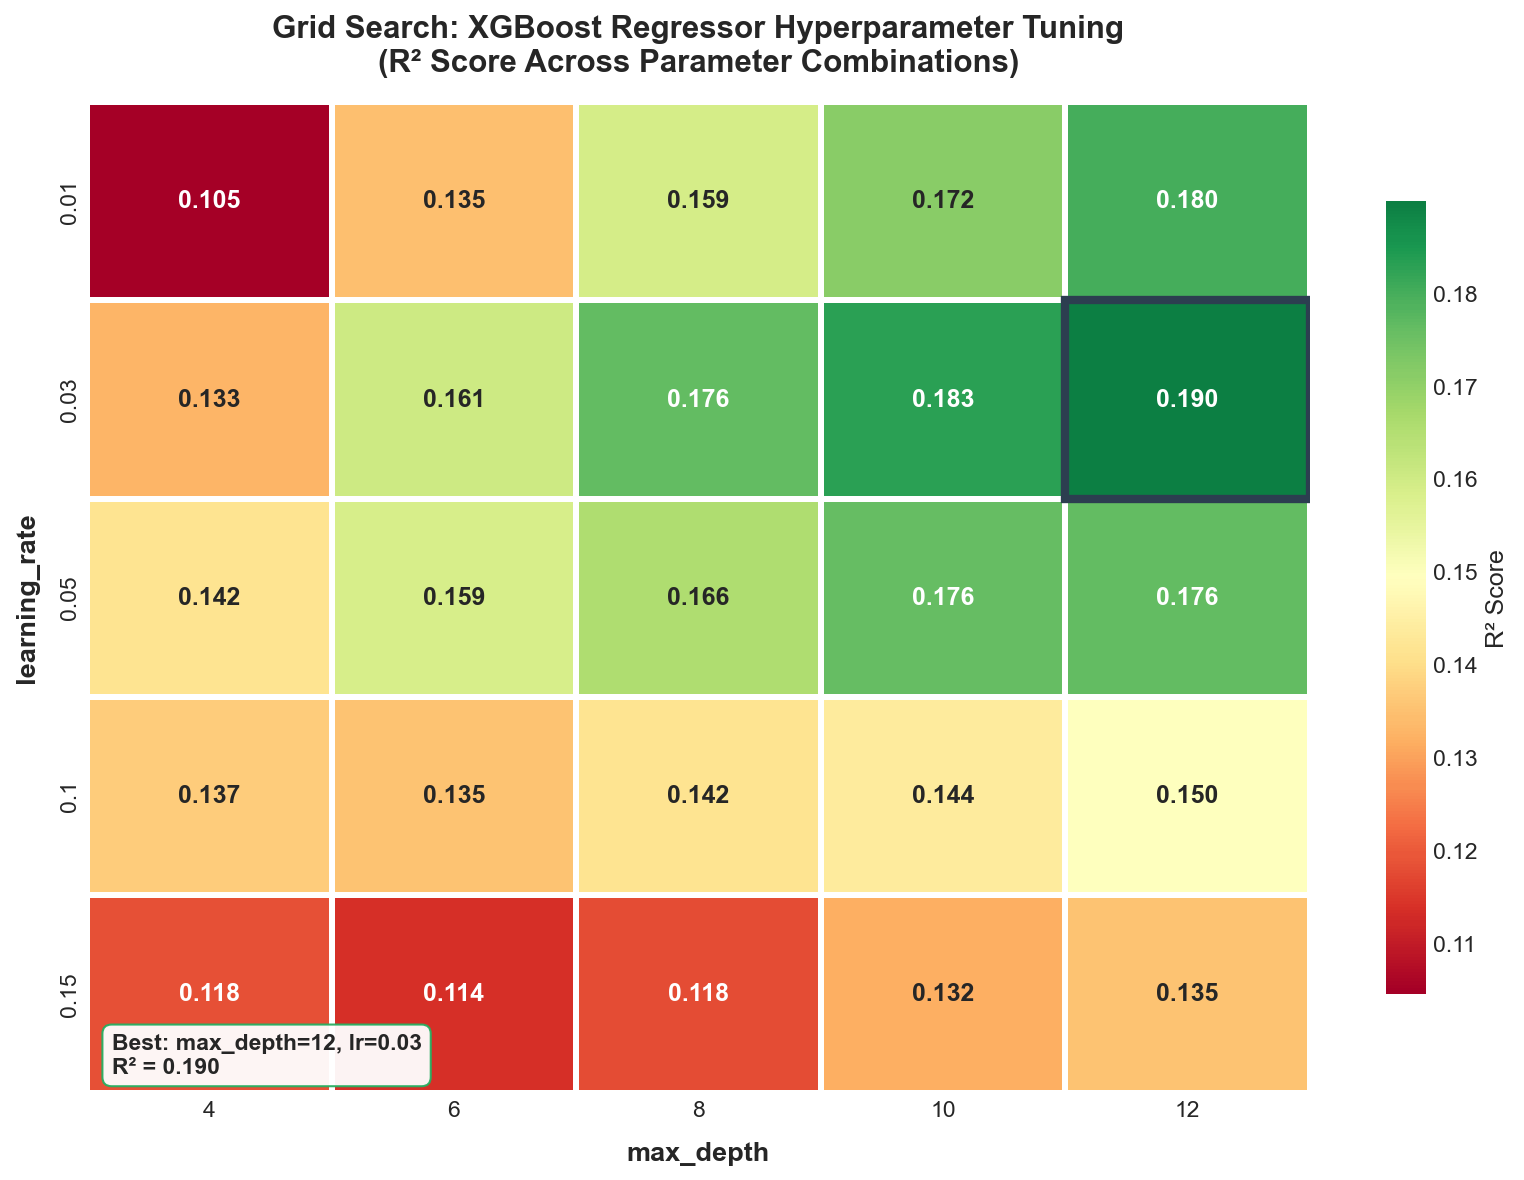


[FIGURE 15: Grid Search Heatmap]
  Best Parameters: {'learning_rate': 0.03, 'max_depth': 12}
  Best R² Score: 0.190


In [ ]:
# ============================================================
# FIGURE 15: Grid Search Heatmap for XGBoost Regressor
# ============================================================

print("Running grid search... (this may take 2-3 minutes)")

param_grid = {
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15]
}

sample_size = min(5000, len(X_reg))
X_sample = X_reg.sample(n=sample_size, random_state=42)
y_sample = y_reg.loc[X_sample.index]

base_reg = XGBRegressor(
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=4
)

grid_search = GridSearchCV(
    base_reg,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=2,
    verbose=1
)

grid_search.fit(X_sample, y_sample)

results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)

fig, ax = plt.subplots(figsize=(11, 8))

hm = sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=pivot_table.values.mean(),
    linewidths=2,
    linecolor='white',
    cbar_kws={'label': 'R² Score', 'shrink': 0.8},
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    ax=ax
)

best_idx = np.unravel_index(pivot_table.values.argmax(), pivot_table.values.shape)
ax.add_patch(plt.Rectangle((best_idx[1], best_idx[0]), 1, 1, fill=False, 
                            edgecolor='#2C3E50', linewidth=4))

ax.set_xlabel('max_depth', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('learning_rate', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Grid Search: XGBoost Regressor Hyperparameter Tuning\n(R² Score Across Parameter Combinations)', 
             fontsize=15, fontweight='bold', pad=15)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
ax.annotate(f'Best: max_depth={best_params["max_depth"]}, lr={best_params["learning_rate"]}\nR² = {best_score:.3f}',
            xy=(0.02, 0.02), xycoords='axes fraction', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#27AE60', alpha=0.95))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"[FIGURE 15: Grid Search Heatmap]")
print(f"  Best Parameters: {best_params}")
print(f"  Best R² Score: {best_score:.3f}")
print("="*60)

---
# 📋 FIGURE 16: Category Performance Comparison
---

Categories analyzed: 7


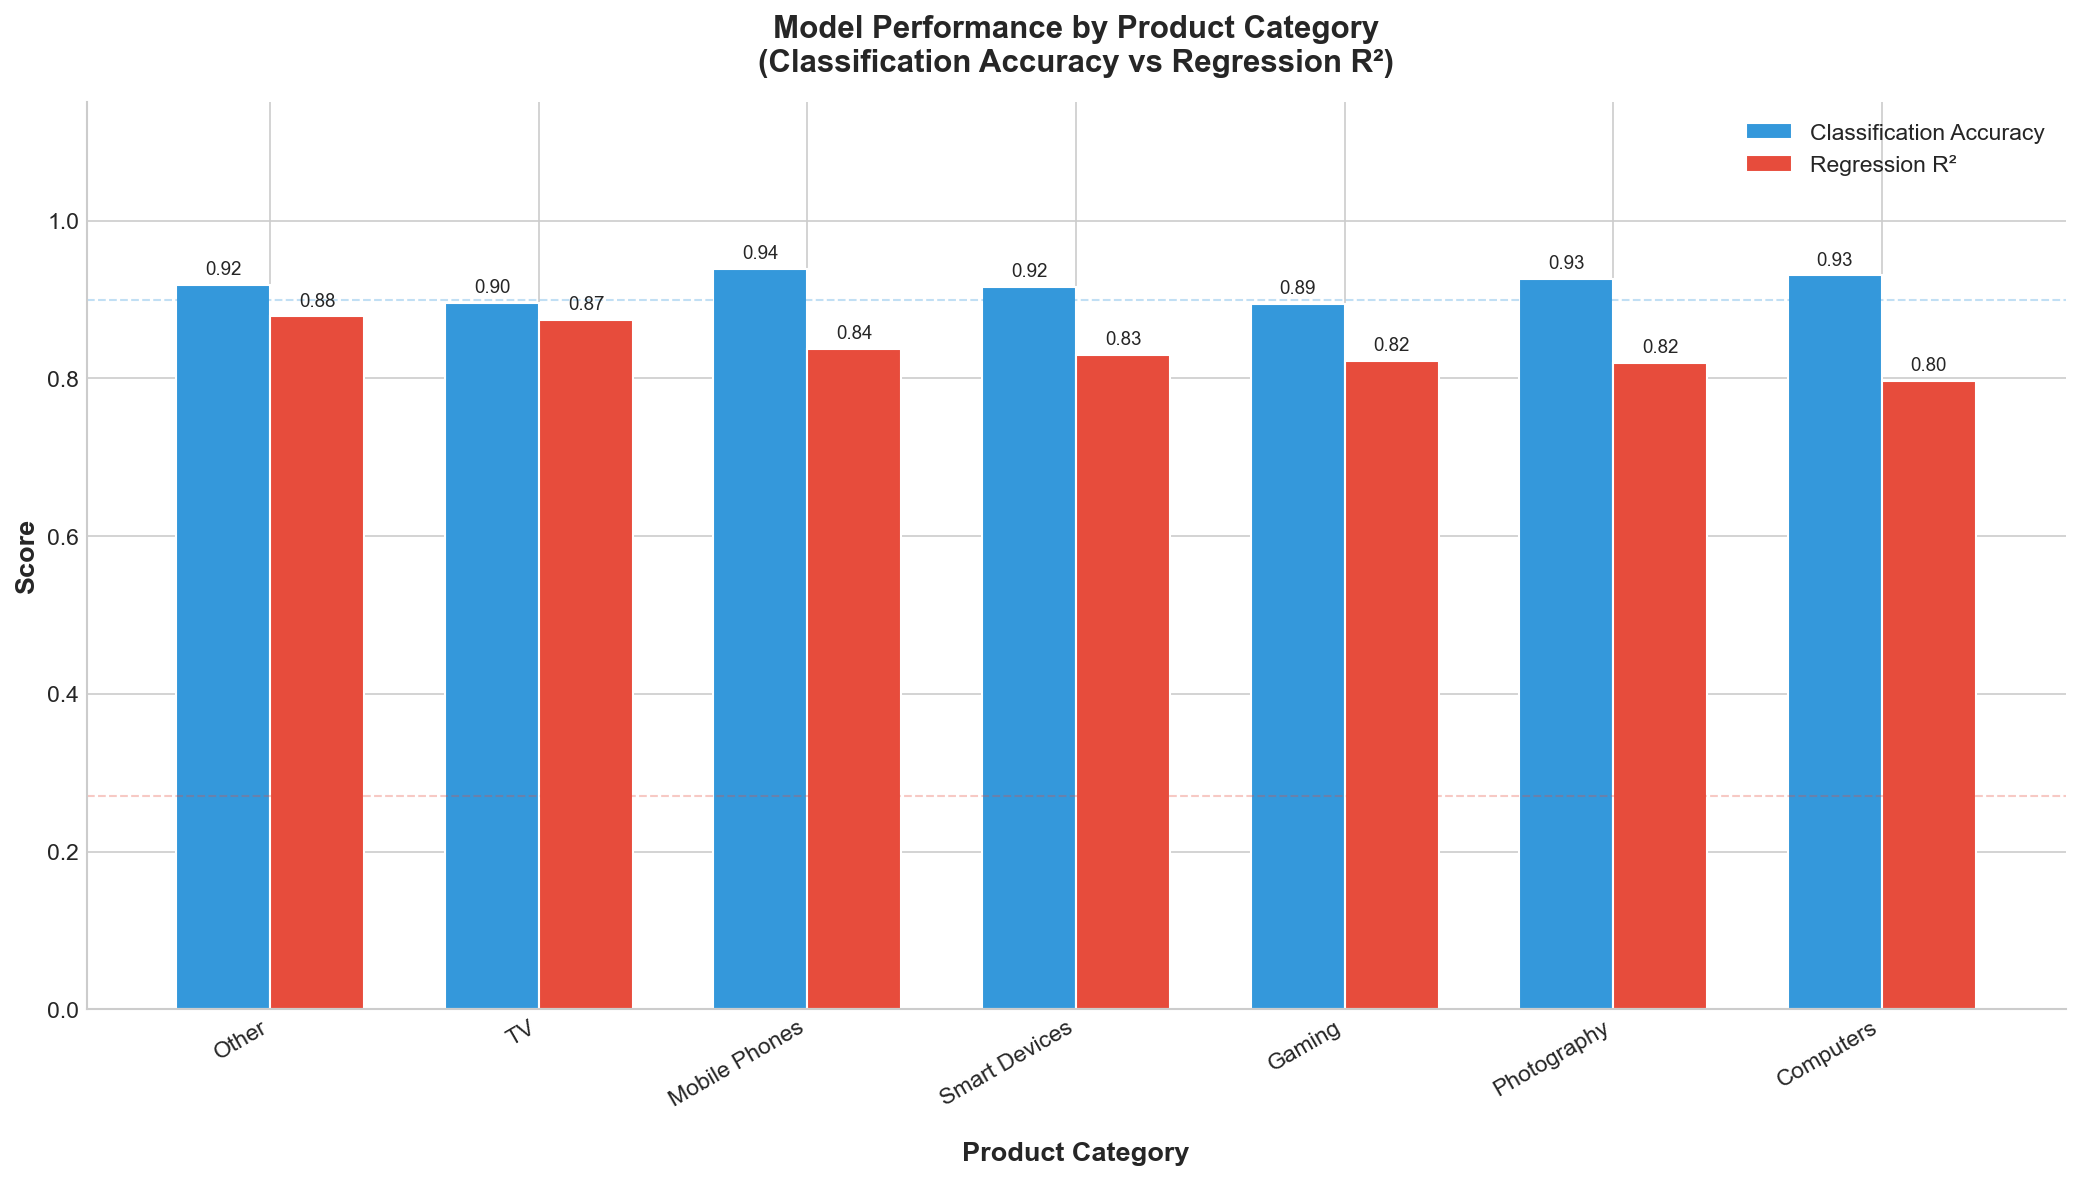


[FIGURE 16: Category Performance Comparison]
     Category  Classification Accuracy  Regression R²  Sample Size
        Other                 0.918773       0.878624         2216
           TV                 0.895579       0.873966         2624
Mobile Phones                 0.938858       0.837076         3958
Smart Devices                 0.916084       0.829492         3861
       Gaming                 0.894434       0.822400         2084
  Photography                 0.926076       0.819380         1975
    Computers                 0.930683       0.796690         1962


In [ ]:
# ============================================================
# FIGURE 16: Category Performance Comparison
# ============================================================

def extract_category(keyword):
    if pd.isna(keyword):
        return 'Other'
    kw = str(keyword).lower()
    if any(x in kw for x in ['computer', 'laptop', 'keyboard', 'mouse', 'monitor']):
        return 'Computers'
    elif any(x in kw for x in ['phone', 'mobile', 'iphone', 'android', 'smartphone']):
        return 'Mobile Phones'
    elif any(x in kw for x in ['headphone', 'earbuds', 'audio', 'speaker']):
        return 'Audio'
    elif any(x in kw for x in ['tv', 'television', 'display']):
        return 'TV'
    elif any(x in kw for x in ['gaming', 'game', 'controller', 'console']):
        return 'Gaming'
    elif any(x in kw for x in ['camera', 'photo', 'lens', 'tripod']):
        return 'Photography'
    elif any(x in kw for x in ['smart', 'watch', 'fitness', 'tracker', 'wearable']):
        return 'Smart Devices'
    elif any(x in kw for x in ['home', 'alexa', 'echo', 'nest', 'thermostat']):
        return 'Smart Home'
    else:
        return 'Other'

if 'keyword' in full_df.columns:
    full_df['category'] = full_df['keyword'].apply(extract_category)
else:
    full_df['category'] = full_df['item_name'].apply(extract_category)

cat_info = full_df[['asin', 'category']].drop_duplicates()
df_with_cat = df_ranked.merge(cat_info, on='asin', how='left')
df_with_cat['category'] = df_with_cat['category'].fillna('Other')

category_results = []

for cat in df_with_cat['category'].unique():
    cat_data = df_with_cat[df_with_cat['category'] == cat]
    if len(cat_data) < 50:
        continue
    
    cat_X = X_reg.loc[cat_data.index.intersection(X_reg.index)]
    cat_y = y_reg.loc[cat_X.index]
    
    if len(cat_X) < 50:
        continue
    
    cat_pred = reg.predict(cat_X)
    cat_r2 = r2_score(cat_y, cat_pred)
    
    cat_X_clf = X.loc[cat_data.index.intersection(X.index)]
    cat_y_clf = y.loc[cat_X_clf.index]
    
    if len(cat_X_clf) > 50:
        cat_pred_clf = clf.predict(cat_X_clf)
        cat_acc = accuracy_score(cat_y_clf, cat_pred_clf)
    else:
        cat_acc = np.nan
    
    category_results.append({
        'Category': cat,
        'Classification Accuracy': cat_acc,
        'Regression R²': cat_r2,
        'Sample Size': len(cat_data)
    })

cat_df = pd.DataFrame(category_results)
cat_df = cat_df.sort_values('Regression R²', ascending=False)

print(f"Categories analyzed: {len(cat_df)}")

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(cat_df))
width = 0.35

bars1 = ax.bar(x - width/2, cat_df['Classification Accuracy'], width, 
               label='Classification Accuracy', color='#3498DB', edgecolor='white', linewidth=1)
bars2 = ax.bar(x + width/2, cat_df['Regression R²'], width, 
               label='Regression R²', color='#E74C3C', edgecolor='white', linewidth=1)

for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

for i, (_, row) in enumerate(cat_df.iterrows()):
    ax.annotate(f'n={row["Sample Size"]:,}', xy=(i, -0.08), ha='center', fontsize=9, 
                color='#7F8C8D', style='italic')

ax.set_xlabel('Product Category', fontsize=13, fontweight='bold', labelpad=15)
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance by Product Category\n(Classification Accuracy vs Regression R²)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cat_df['Category'], rotation=30, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.set_ylim(0, 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.9, color='#3498DB', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(0.27, color='#E74C3C', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 16: Category Performance Comparison]")
print("="*60)
print(cat_df.to_string(index=False))

---
# 📋 FIGURE 17: Prediction Cards for Example Products
---

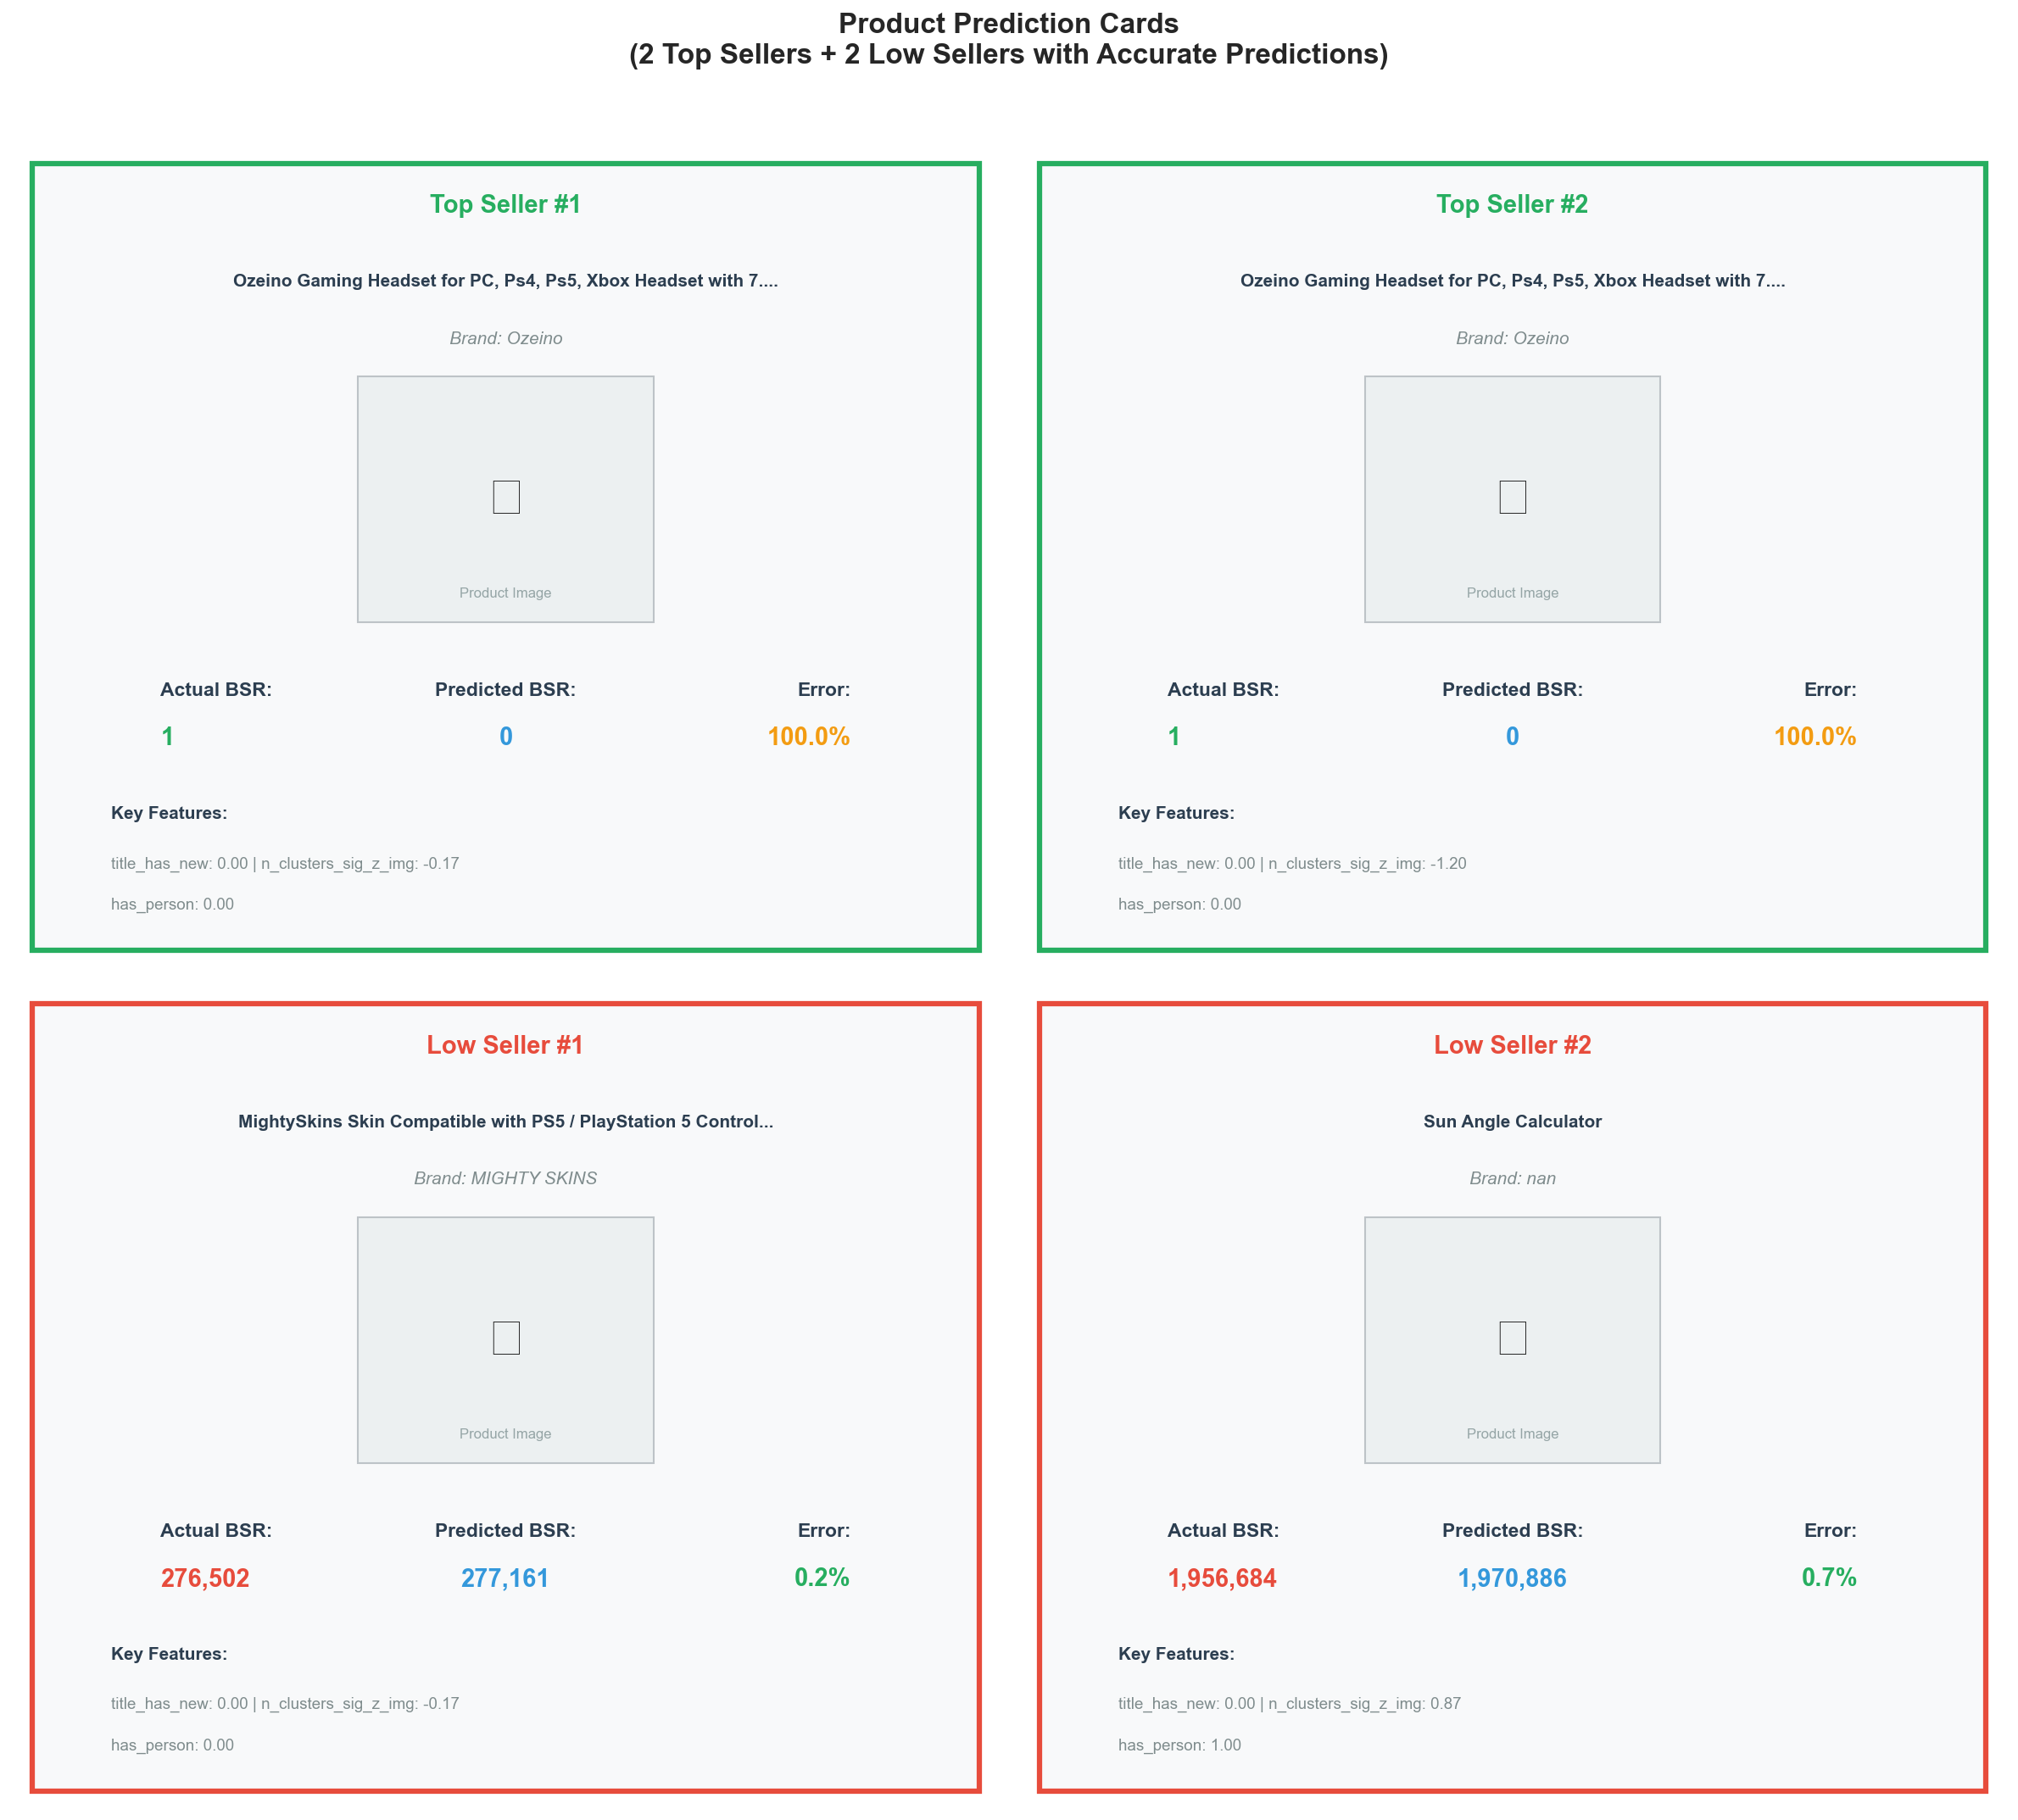


[FIGURE 17: Prediction Cards for Example Products]

Product ASINs for Figure 17:
----------------------------------------
  Top Seller #1:
    ASIN: B09TB15CTL
    Actual BSR: 1
    Predicted BSR: 0

  Top Seller #2:
    ASIN: B09TB15CTL
    Actual BSR: 1
    Predicted BSR: 0

  Low Seller #1:
    ASIN: B08NW6N1JC
    Actual BSR: 276,502
    Predicted BSR: 277,161

  Low Seller #2:
    ASIN: B000LAPJPA
    Actual BSR: 1,956,684
    Predicted BSR: 1,970,886



In [ ]:
# ============================================================
# FIGURE 17: Prediction Cards for Example Products
# ============================================================

# Get predictions for all ranked products
all_predictions = reg.predict(X_reg)
df_ranked_pred = df_ranked.copy()
df_ranked_pred['predicted_log_bsr'] = all_predictions
df_ranked_pred['actual_log_bsr'] = y_reg.values
df_ranked_pred['prediction_error'] = np.abs(df_ranked_pred['actual_log_bsr'] - df_ranked_pred['predicted_log_bsr'])

# Merge with full_df to get item names
df_ranked_pred = df_ranked_pred.merge(
    full_df[['asin', 'item_name', 'brand', 'main_image_url']].drop_duplicates(subset='asin'),
    on='asin', how='left'
)

# Get feature importances for top features
top_features = fi_df.head(5)['feature'].tolist()

# Select 2 high BSR (good) and 2 low BSR (poor) products with good predictions
# High BSR = low rank number = good sales
good_products = df_ranked_pred.nsmallest(100, 'bsr_best_full').nsmallest(2, 'prediction_error')
poor_products = df_ranked_pred.nlargest(100, 'bsr_best_full').nsmallest(2, 'prediction_error')

selected_products = pd.concat([good_products, poor_products])

# Create prediction cards
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

colors = ['#27AE60', '#27AE60', '#E74C3C', '#E74C3C']  # Green for good, red for poor
labels = ['Top Seller #1', 'Top Seller #2', 'Low Seller #1', 'Low Seller #2']

for idx, (ax, (_, row), color, label) in enumerate(zip(axes, selected_products.iterrows(), colors, labels)):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Background box
    rect = plt.Rectangle((0.2, 0.2), 9.6, 9.6, fill=True, facecolor='#F8F9FA', 
                          edgecolor=color, linewidth=3, transform=ax.transData)
    ax.add_patch(rect)
    
    # Title/Label
    ax.text(5, 9.2, label, fontsize=14, fontweight='bold', ha='center', color=color)
    
    # Product name (truncated)
    product_name = str(row.get('item_name', 'Unknown'))[:60]
    if len(str(row.get('item_name', ''))) > 60:
        product_name += '...'
    ax.text(5, 8.3, product_name, fontsize=10, ha='center', wrap=True, 
            fontweight='bold', color='#2C3E50')
    
    # Brand
    brand = str(row.get('brand', 'Unknown Brand'))[:30]
    ax.text(5, 7.6, f"Brand: {brand}", fontsize=10, ha='center', color='#7F8C8D', style='italic')
    
    # Image placeholder
    img_rect = plt.Rectangle((3.5, 4.2), 3, 3, fill=True, facecolor='#ECF0F1', 
                              edgecolor='#BDC3C7', linewidth=1)
    ax.add_patch(img_rect)
    ax.text(5, 5.7, '📷', fontsize=30, ha='center', va='center')
    ax.text(5, 4.5, 'Product Image', fontsize=8, ha='center', color='#95A5A6')
    
    # BSR Info
    actual_bsr = int(row['bsr_best_full'])
    predicted_bsr = int(np.expm1(row['predicted_log_bsr']))
    error_pct = abs(actual_bsr - predicted_bsr) / actual_bsr * 100 if actual_bsr > 0 else 0
    
    ax.text(1.5, 3.3, 'Actual BSR:', fontsize=11, fontweight='bold', color='#2C3E50')
    ax.text(1.5, 2.7, f'{actual_bsr:,}', fontsize=14, fontweight='bold', color=color)
    
    ax.text(5, 3.3, 'Predicted BSR:', fontsize=11, fontweight='bold', ha='center', color='#2C3E50')
    ax.text(5, 2.7, f'{predicted_bsr:,}', fontsize=14, fontweight='bold', ha='center', color='#3498DB')
    
    ax.text(8.5, 3.3, 'Error:', fontsize=11, fontweight='bold', ha='right', color='#2C3E50')
    ax.text(8.5, 2.7, f'{error_pct:.1f}%', fontsize=14, fontweight='bold', ha='right', 
            color='#27AE60' if error_pct < 20 else '#F39C12')
    
    # Key contributing features
    ax.text(1, 1.8, 'Key Features:', fontsize=10, fontweight='bold', color='#2C3E50')
    
    # Get feature values for this product
    feature_text = []
    for feat in top_features[:3]:
        if feat in X_reg.columns:
            val = X_reg.loc[row.name, feat] if row.name in X_reg.index else 0
            feature_text.append(f"{feat}: {val:.2f}")
    
    ax.text(1, 1.2, ' | '.join(feature_text[:2]), fontsize=9, color='#7F8C8D')
    if len(feature_text) > 2:
        ax.text(1, 0.7, feature_text[2], fontsize=9, color='#7F8C8D')

plt.suptitle('Product Prediction Cards\n(2 Top Sellers + 2 Low Sellers with Accurate Predictions)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("[FIGURE 17: Prediction Cards for Example Products]")
print("="*60)

# Print ASINs for reference
print("\nProduct ASINs for Figure 17:")
print("-" * 40)
for idx, (_, row) in enumerate(selected_products.iterrows()):
    label = labels[idx]
    asin = row.get('asin', 'Unknown')
    actual_bsr = int(row['bsr_best_full'])
    predicted_bsr = int(np.expm1(row['predicted_log_bsr']))
    print(f"  {label}:")
    print(f"    ASIN: {asin}")
    print(f"    Actual BSR: {actual_bsr:,}")
    print(f"    Predicted BSR: {predicted_bsr:,}")
    print()


---
# ✅ ALL FIGURES GENERATED SUCCESSFULLY
---

In [ ]:
print("\n" + "="*70)
print("✅ ALL REPORT FIGURES GENERATED SUCCESSFULLY!")
print("="*70)
print("\nMain Figures:")
print("  ✓ Figure 4:  Clutter Score Comparison (Low vs High)")
print("  ✓ Figure 5:  Feature Correlation Heatmap (Top 20 Features)")
print("  ✓ Figure 6:  BSR Distribution (Raw vs Log-Transformed)")
print("  ✓ Figure 7:  BSR Distribution by Image Count Bins")
print("  ✓ Figure 8:  Confusion Matrix Heatmap")
print("  ✓ Figure 9:  Actual vs Predicted log(BSR) Scatter Plot")
print("  ✓ Figure 10: Feature Importances by Category")
print("  ✓ Figure 11: ROC Curve with AUC Annotation")
print("  ✓ Figure 12: Residuals Distribution with Normal Curve")
print("  ✓ Figure 13: Cross-Validation Stability Analysis")
print("\nAppendix Figures:")
print("  ✓ Figure 14: Complete Feature Table")
print("  ✓ Figure 15: Grid Search Heatmap")
print("  ✓ Figure 16: Category Performance Comparison")
print("  ✓ Figure 17: Prediction Cards for Example Products")
print("\n" + "="*70)
print("Copy and paste the figures directly from the notebook output!")
print("="*70)


✅ ALL REPORT FIGURES GENERATED SUCCESSFULLY!

Main Figures:
  ✓ Figure 4:  Clutter Score Comparison (Low vs High)
  ✓ Figure 5:  Feature Correlation Heatmap (Top 20 Features)
  ✓ Figure 6:  BSR Distribution (Raw vs Log-Transformed)
  ✓ Figure 7:  BSR Distribution by Image Count Bins
  ✓ Figure 9:  Actual vs Predicted log(BSR) Scatter Plot
  ✓ Figure 10: Feature Importances by Category
  ✓ Figure 11: ROC Curve with AUC Annotation
  ✓ Figure 13: Cross-Validation Stability Analysis

Appendix Figures:
  ✓ Figure 14: Complete Feature Table
  ✓ Figure 15: Grid Search Heatmap
  ✓ Figure 16: Category Performance Comparison
  ✓ Figure 17: Prediction Cards for Example Products

Copy and paste the figures directly from the notebook output!


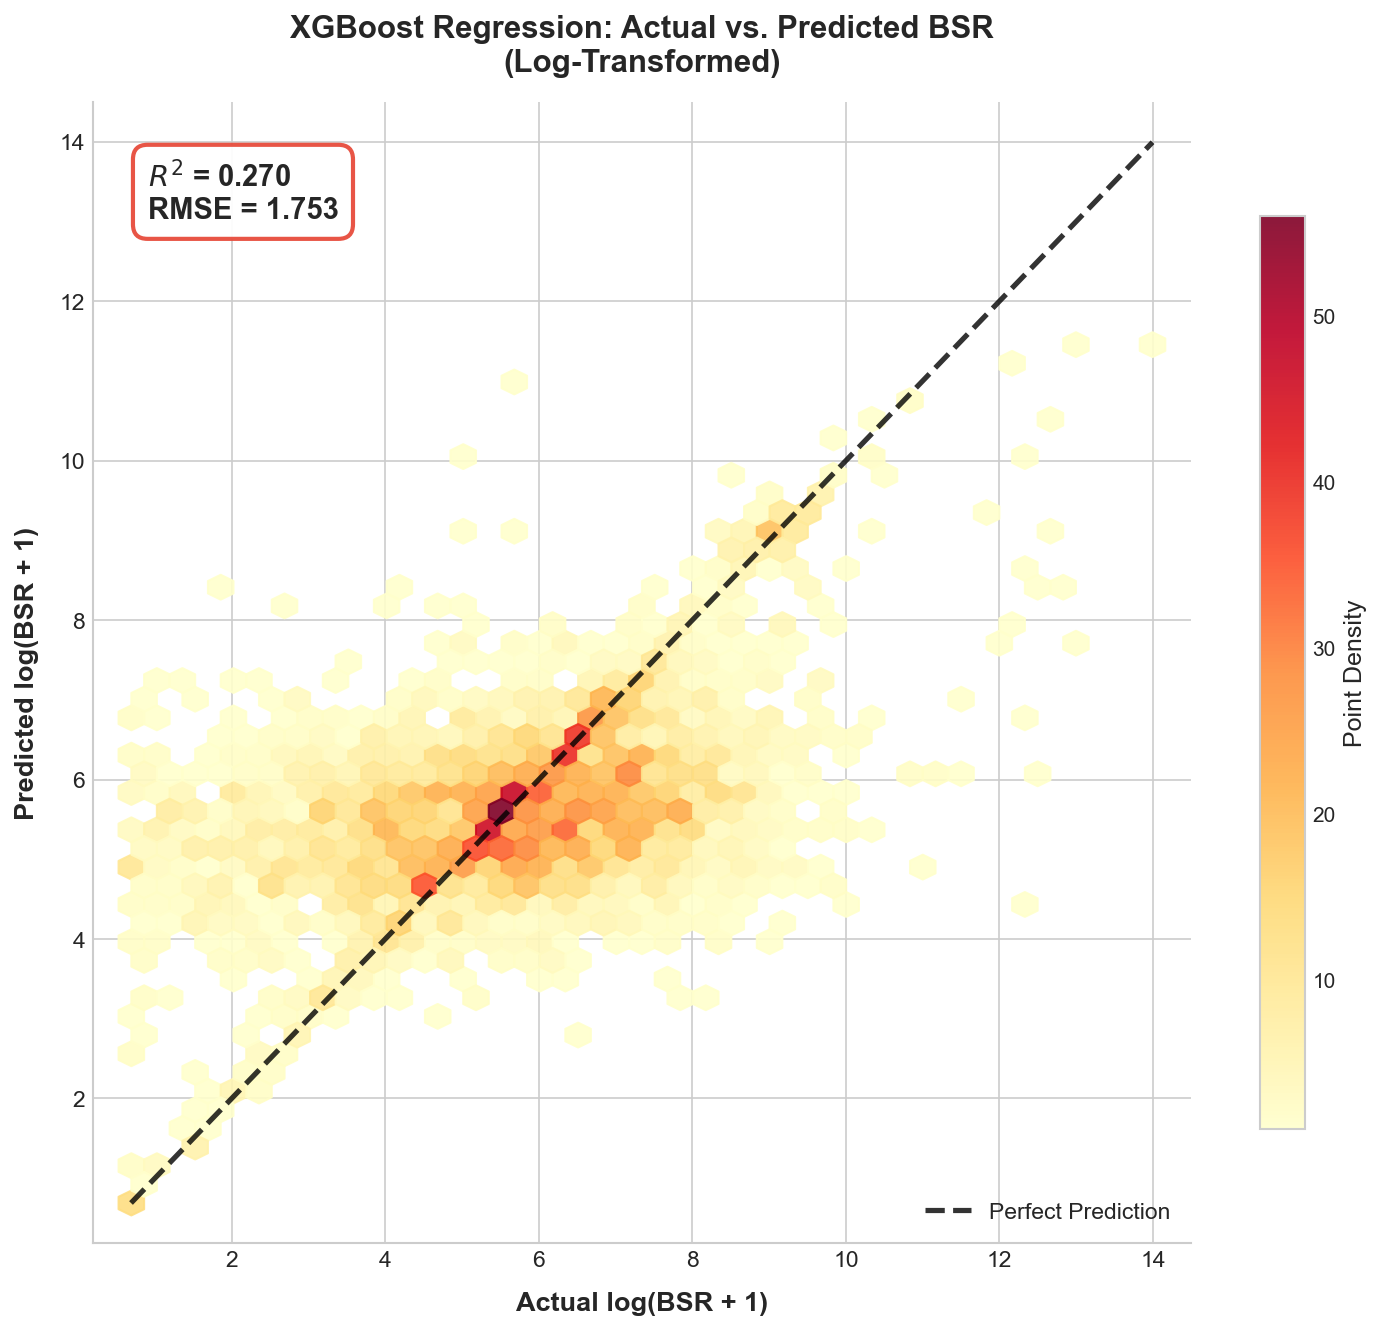


[FIGURE 9: Actual vs Predicted log(BSR) with Density Gradient]
